Device: cuda
Episode 0 | Self-model loss: 0.08997644
Episode 1000 | Self-model loss: 0.00000156
Episode 2000 | Self-model loss: 0.00000121
Episode 3000 | Self-model loss: 0.00000106
Episode 4000 | Self-model loss: 0.00000141
Episode 5000 | Self-model loss: 0.00000149
Episode 6000 | Self-model loss: 0.00000126
Episode 7000 | Self-model loss: 0.00000211
Episode 8000 | Self-model loss: 0.00000051
Episode 9000 | Self-model loss: 0.00000056
Child episode 0 | Loss: 0.16392934
Child episode 1000 | Loss: 0.00063362
Child episode 2000 | Loss: 0.00024432
Child episode 3000 | Loss: 0.00006501
Child episode 4000 | Loss: 0.00004211
Child episode 5000 | Loss: 0.00000863
Child episode 6000 | Loss: 0.00001331
Child episode 7000 | Loss: 0.00001433
Child episode 8000 | Loss: 0.00001172
Child episode 9000 | Loss: 0.00000879

Parent vs Self-model MSE: 2.2747381080989726e-06
Parent vs Child MSE: 1.063252602762077e-05


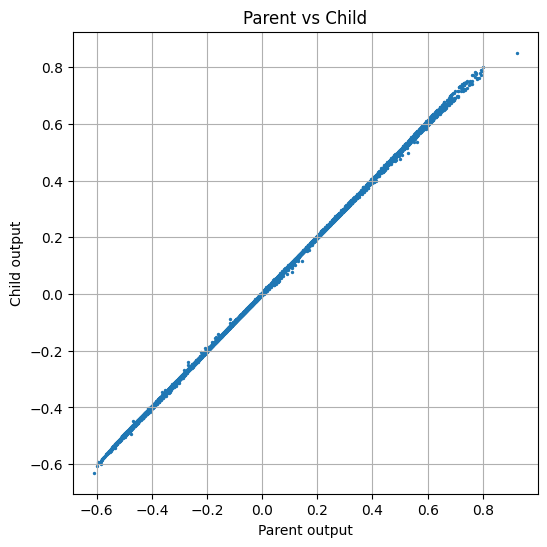

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


# ============================================================
# 1. PARENT
# ============================================================

class Parent(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)


parent = Parent().to(device)

# Parent tamamen sabit
for p in parent.parameters():
    p.requires_grad = False


# ============================================================
# 2. CHILD
# ============================================================

class Child(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)


child = Child().to(device)


# ============================================================
# 3. SELF-MODEL
# ============================================================

class SelfModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)


self_model = SelfModel().to(device)


# ============================================================
# 4. SELF-MODEL LEARNS PARENT BEHAVIOR
# ============================================================

optimizer = optim.Adam(
    self_model.parameters(),
    lr=1e-3
)

loss_fn = nn.MSELoss()


for episode in range(10000):

    # Self-model kendi deneyini yapıyor
    x = torch.randn(256, 2).to(device)

    # Parent'a soru sor
    with torch.no_grad():
        y_parent = parent(x)

    # Self-model parent davranışını öğreniyor
    y_pred = self_model(x)

    loss = loss_fn(y_pred, y_parent)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if episode % 1000 == 0:
        print(
            f"Episode {episode} | "
            f"Self-model loss: {loss.item():.8f}"
        )


# ============================================================
# 5. CHILD TRAINED FROM SELF-MODEL
# ============================================================

child_optimizer = optim.Adam(
    child.parameters(),
    lr=1e-3
)

for episode in range(10000):

    x = torch.randn(256, 2).to(device)

    with torch.no_grad():
        y_self = self_model(x)

    y_child = child(x)

    loss = loss_fn(y_child, y_self)

    child_optimizer.zero_grad()
    loss.backward()
    child_optimizer.step()

    if episode % 1000 == 0:
        print(
            f"Child episode {episode} | "
            f"Loss: {loss.item():.8f}"
        )


# ============================================================
# 6. NEVER-SEEN TEST
# ============================================================

x_test = torch.randn(10000, 2).to(device)

with torch.no_grad():
    y_parent = parent(x_test)
    y_self = self_model(x_test)
    y_child = child(x_test)

self_error = torch.mean(
    (y_parent - y_self) ** 2
).item()

child_error = torch.mean(
    (y_parent - y_child) ** 2
).item()

print()
print("Parent vs Self-model MSE:", self_error)
print("Parent vs Child MSE:", child_error)


# ============================================================
# 7. VISUALIZATION
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    y_parent.cpu(),
    y_child.cpu(),
    s=2
)

plt.xlabel("Parent output")
plt.ylabel("Child output")
plt.title("Parent vs Child")

plt.grid()
plt.show()

Device: cuda
Episode 0 | Self-identification loss: 0.14823756
Episode 500 | Self-identification loss: 0.10320871
Episode 1000 | Self-identification loss: 0.05006646
Episode 1500 | Self-identification loss: 0.01872146
Episode 2000 | Self-identification loss: 0.06023783
Episode 2500 | Self-identification loss: 0.05238558
Episode 3000 | Self-identification loss: 0.05734436
Episode 3500 | Self-identification loss: 0.07008064
Episode 4000 | Self-identification loss: 0.01912612
Episode 4500 | Self-identification loss: 0.01012934

Training finished.

Queries selected by the self-model:
Query 1: [0.0228, -0.0292]
Query 2: [0.0154, -0.0282]
Query 3: [0.0123, -0.0289]
Query 4: [0.0115, -0.0293]
Query 5: [0.0111, -0.0296]
Query 6: [0.0110, -0.0298]
Query 7: [0.0109, -0.0299]
Query 8: [0.0108, -0.0299]

Final Parent vs Self-model MSE: 0.005742805544286966


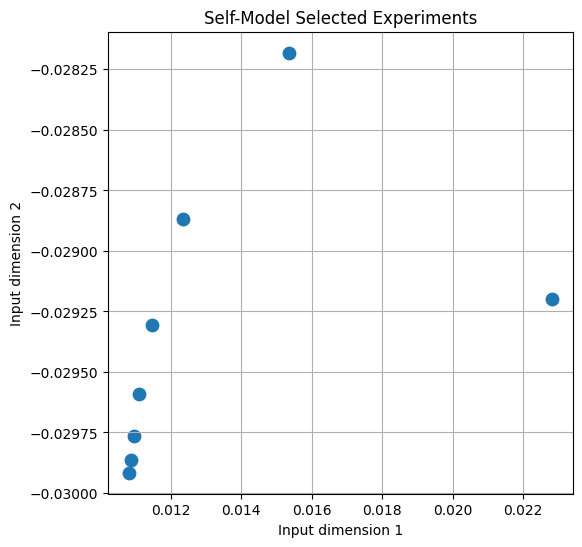

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)


# ============================================================
# 1. HIDDEN PARENT
# ============================================================

class Parent(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )

    def forward(self, x):

        return self.net(x)


# ============================================================
# 2. SELF-MODEL
# ============================================================

class SelfModel(nn.Module):

    def __init__(self, hidden=128):

        super().__init__()

        # Observed experiment:
        # x1, x2, y

        self.encoder = nn.Sequential(
            nn.Linear(3, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )

        # Memory of experiments

        self.memory = nn.GRU(
            input_size=hidden,
            hidden_size=hidden,
            batch_first=True
        )

        # Predict unseen parent behavior

        self.predictor = nn.Sequential(
            nn.Linear(hidden + 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

        # Choose next experiment

        self.query_policy = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2),
            nn.Tanh()
        )

    def encode_experiment(self, x, y):

        obs = torch.cat([x, y], dim=-1)

        z = self.encoder(obs)

        return z

    def update_memory(self, history):

        z = self.encoder(history)

        _, h = self.memory(z)

        return h[-1]

    def predict(self, state, x):

        state_x = torch.cat(
            [state, x],
            dim=-1
        )

        return self.predictor(state_x)

    def choose_query(self, state):

        return self.query_policy(state)


# ============================================================
# 3. DIFFERENT CHILD ARCHITECTURE
# ============================================================

class Child(nn.Module):

    def __init__(self):

        super().__init__()

        # Parent:
        # 2 → 8 → Tanh → 1

        # Child:
        # 2 → 32 → ReLU → 32 → 1

        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.net(x)


# ============================================================
# 4. ACTIVE SELF-IDENTIFICATION
# ============================================================

self_model = SelfModel().to(device)

optimizer = optim.Adam(
    self_model.parameters(),
    lr=1e-3
)

loss_fn = nn.MSELoss()

N_EPISODES = 5000
N_QUERIES = 8
N_TEST = 128


for episode in range(N_EPISODES):

    # --------------------------------------------------------
    # NEW HIDDEN PARENT
    # --------------------------------------------------------

    parent = Parent().to(device)

    # --------------------------------------------------------
    # INITIAL MEMORY
    # --------------------------------------------------------

    history = []

    state = torch.zeros(
        1,
        128,
        device=device
    )

    # --------------------------------------------------------
    # SELF-DIRECTED EXPERIMENTS
    # --------------------------------------------------------

    for q in range(N_QUERIES):

        # Self-model chooses query

        query = self_model.choose_query(state)

        # Ask parent

        query_parent = parent(query)

        # Store experiment

        experiment = torch.cat(
            [query, query_parent],
            dim=-1
        )

        history.append(experiment)

        # Convert history to sequence

        history_tensor = torch.stack(
            history,
            dim=1
        )

        # Update memory

        state = self_model.update_memory(
            history_tensor
        )

    # --------------------------------------------------------
    # TEST UNSEEN BEHAVIOR
    # --------------------------------------------------------

    x_test = torch.randn(
        N_TEST,
        2,
        device=device
    )

    with torch.no_grad():

        y_parent = parent(x_test)

    state_expanded = state.expand(
        N_TEST,
        -1
    )

    y_pred = self_model.predict(
        state_expanded,
        x_test
    )

    loss = loss_fn(
        y_pred,
        y_parent
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if episode % 500 == 0:

        print(
            f"Episode {episode} | "
            f"Self-identification loss: "
            f"{loss.item():.8f}"
        )


# ============================================================
# 5. INSPECT QUERY STRATEGY
# ============================================================

print("\nTraining finished.")

parent = Parent().to(device)

history = []

state = torch.zeros(
    1,
    128,
    device=device
)

queries = []

for q in range(N_QUERIES):

    with torch.no_grad():

        query = self_model.choose_query(state)

        y = parent(query)

    queries.append(
        query.squeeze().cpu()
    )

    experiment = torch.cat(
        [query, y],
        dim=-1
    )

    history.append(experiment)

    history_tensor = torch.stack(
        history,
        dim=1
    )

    state = self_model.update_memory(
        history_tensor
    )


queries = torch.stack(queries)

print("\nQueries selected by the self-model:")

for i, q in enumerate(queries):

    print(
        f"Query {i+1}: "
        f"[{q[0].item():.4f}, "
        f"{q[1].item():.4f}]"
    )


# ============================================================
# 6. FINAL GENERALIZATION TEST
# ============================================================

x_test = torch.randn(
    10000,
    2,
    device=device
)

with torch.no_grad():

    y_parent = parent(x_test)

state_expanded = state.expand(
    x_test.shape[0],
    -1
)

with torch.no_grad():

    y_self = self_model.predict(
        state_expanded,
        x_test
    )

final_mse = torch.mean(
    (y_parent - y_self) ** 2
).item()

print(
    "\nFinal Parent vs Self-model MSE:",
    final_mse
)


# ============================================================
# 7. VISUALIZE QUERY STRATEGY
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    queries[:, 0],
    queries[:, 1],
    s=80
)

plt.xlabel("Input dimension 1")

plt.ylabel("Input dimension 2")

plt.title(
    "Self-Model Selected Experiments"
)

plt.grid()

plt.show()

Episode 0 | Uncertainty loss: -0.036197
Episode 500 | Uncertainty loss: -1.059236
Episode 1000 | Uncertainty loss: -0.909880
Episode 1500 | Uncertainty loss: -0.438933
Episode 2000 | Uncertainty loss: -1.030786
Episode 2500 | Uncertainty loss: -0.903237
Episode 3000 | Uncertainty loss: -1.196586
Episode 3500 | Uncertainty loss: -0.810603
Episode 4000 | Uncertainty loss: -0.913848
Episode 4500 | Uncertainty loss: -1.392865

Cell 3 training finished.

Uncertainty-driven queries:
Query 1: [0.9984, 0.8970] | Uncertainty: -0.0347
Query 2: [-0.9485, 0.6911] | Uncertainty: -0.8324
Query 3: [0.8372, -0.9608] | Uncertainty: -2.7217
Query 4: [0.8688, -0.9742] | Uncertainty: -3.4356
Query 5: [0.4857, -0.9802] | Uncertainty: -3.6811
Query 6: [-0.1112, -0.9897] | Uncertainty: -3.8172
Query 7: [0.7232, -0.9947] | Uncertainty: -3.9536
Query 8: [0.3297, -0.9961] | Uncertainty: -3.9842

Cell 3 Parent vs Self-model MSE: 0.01603386551141739


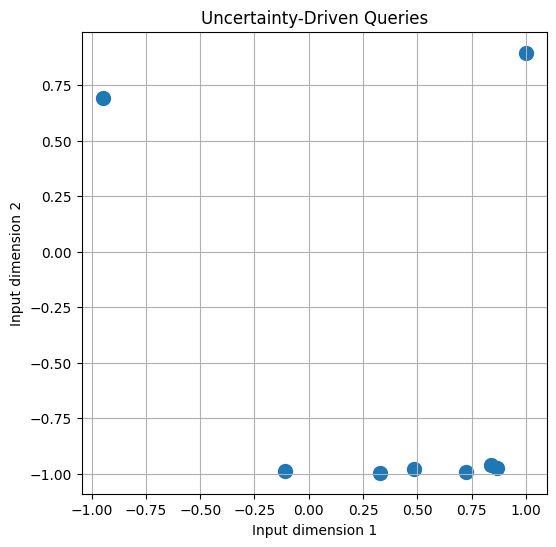

In [ ]:
# ============================================================
# CELL 3
# UNCERTAINTY-DRIVEN ACTIVE SELF-IDENTIFICATION
# ============================================================

class UncertaintySelfModel(nn.Module):

    def __init__(self, hidden=128):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(3, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )

        self.memory = nn.GRU(
            input_size=hidden,
            hidden_size=hidden,
            batch_first=True
        )

        # Mean + uncertainty

        self.predictor = nn.Sequential(
            nn.Linear(hidden + 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2)
        )

    def update_memory(self, history):

        encoded_history = self.encoder(history)

        _, hidden_state = self.memory(
            encoded_history
        )

        return hidden_state[-1]

    def predict(self, state, x):

        state_x = torch.cat(
            [state, x],
            dim=-1
        )

        output = self.predictor(state_x)

        mean = output[:, 0:1]

        log_variance = output[:, 1:2]

        return mean, log_variance


# ============================================================
# NEW MODEL
# ============================================================

uncertainty_self_model = UncertaintySelfModel().to(device)

uncertainty_optimizer = optim.Adam(
    uncertainty_self_model.parameters(),
    lr=1e-3
)


# ============================================================
# TRAINING PARAMETERS
# ============================================================

uncertainty_episodes = 5000

uncertainty_queries = 8

candidate_queries = 256

uncertainty_test_size = 128


# ============================================================
# ACTIVE LEARNING
# ============================================================

for uncertainty_episode in range(
    uncertainty_episodes
):

    uncertainty_parent = Parent().to(device)

    uncertainty_history = []

    uncertainty_state = torch.zeros(
        1,
        128,
        device=device
    )

    for uncertainty_step in range(
        uncertainty_queries
    ):

        # ----------------------------------------------------
        # CANDIDATE EXPERIMENTS
        # ----------------------------------------------------

        candidate_x = torch.rand(
            candidate_queries,
            2,
            device=device
        ) * 2.0 - 1.0

        candidate_state = uncertainty_state.expand(
            candidate_queries,
            -1
        )

        with torch.no_grad():

            candidate_mean, candidate_logvar = \
                uncertainty_self_model.predict(
                    candidate_state,
                    candidate_x
                )

        # ----------------------------------------------------
        # SELECT MOST UNCERTAIN QUERY
        # ----------------------------------------------------

        most_uncertain_index = torch.argmax(
            candidate_logvar[:, 0]
        )

        uncertainty_query = candidate_x[
            most_uncertain_index
        ].unsqueeze(0)

        # ----------------------------------------------------
        # ASK PARENT
        # ----------------------------------------------------

        with torch.no_grad():

            uncertainty_parent_output = \
                uncertainty_parent(
                    uncertainty_query
                )

        # ----------------------------------------------------
        # STORE EXPERIMENT
        # ----------------------------------------------------

        uncertainty_experiment = torch.cat(
            [
                uncertainty_query,
                uncertainty_parent_output
            ],
            dim=-1
        )

        uncertainty_history.append(
            uncertainty_experiment
        )

        uncertainty_history_tensor = torch.stack(
            uncertainty_history,
            dim=1
        )

        uncertainty_state = \
            uncertainty_self_model.update_memory(
                uncertainty_history_tensor
            )

    # ========================================================
    # GENERALIZATION TEST
    # ========================================================

    uncertainty_x_test = torch.randn(
        uncertainty_test_size,
        2,
        device=device
    )

    with torch.no_grad():

        uncertainty_y_parent = \
            uncertainty_parent(
                uncertainty_x_test
            )

    uncertainty_state_expanded = \
        uncertainty_state.expand(
            uncertainty_test_size,
            -1
        )

    uncertainty_y_mean, uncertainty_logvar = \
        uncertainty_self_model.predict(
            uncertainty_state_expanded,
            uncertainty_x_test
        )

    # ========================================================
    # GAUSSIAN NLL
    # ========================================================

    uncertainty_variance = torch.exp(
        uncertainty_logvar
    )

    uncertainty_loss = torch.mean(
        0.5 * (
            uncertainty_logvar
            + (
                uncertainty_y_parent
                - uncertainty_y_mean
            ) ** 2
            / uncertainty_variance
        )
    )

    uncertainty_optimizer.zero_grad()

    uncertainty_loss.backward()

    uncertainty_optimizer.step()

    if uncertainty_episode % 500 == 0:

        print(
            f"Episode {uncertainty_episode} | "
            f"Uncertainty loss: "
            f"{uncertainty_loss.item():.6f}"
        )


print("\nCell 3 training finished.")


# ============================================================
# QUERY INSPECTION
# ============================================================

inspection_parent = Parent().to(device)

inspection_history = []

inspection_state = torch.zeros(
    1,
    128,
    device=device
)

inspection_queries = []

inspection_uncertainties = []


for inspection_step in range(
    uncertainty_queries
):

    inspection_candidate_x = torch.rand(
        candidate_queries,
        2,
        device=device
    ) * 2.0 - 1.0

    inspection_candidate_state = \
        inspection_state.expand(
            candidate_queries,
            -1
        )

    with torch.no_grad():

        inspection_mean, inspection_logvar = \
            uncertainty_self_model.predict(
                inspection_candidate_state,
                inspection_candidate_x
            )

    inspection_index = torch.argmax(
        inspection_logvar[:, 0]
    )

    inspection_query = inspection_candidate_x[
        inspection_index
    ].unsqueeze(0)

    inspection_uncertainty = \
        inspection_logvar[
            inspection_index
        ].item()

    with torch.no_grad():

        inspection_output = \
            inspection_parent(
                inspection_query
            )

    inspection_experiment = torch.cat(
        [
            inspection_query,
            inspection_output
        ],
        dim=-1
    )

    inspection_history.append(
        inspection_experiment
    )

    inspection_history_tensor = torch.stack(
        inspection_history,
        dim=1
    )

    inspection_state = \
        uncertainty_self_model.update_memory(
            inspection_history_tensor
        )

    inspection_queries.append(
        inspection_query.squeeze().cpu()
    )

    inspection_uncertainties.append(
        inspection_uncertainty
    )


inspection_queries = torch.stack(
    inspection_queries
)


print("\nUncertainty-driven queries:")

for inspection_i, inspection_query in enumerate(
    inspection_queries
):

    print(
        f"Query {inspection_i + 1}: "
        f"["
        f"{inspection_query[0].item():.4f}, "
        f"{inspection_query[1].item():.4f}"
        f"] | "
        f"Uncertainty: "
        f"{inspection_uncertainties[inspection_i]:.4f}"
    )


# ============================================================
# FINAL TEST
# ============================================================

cell3_test_x = torch.randn(
    10000,
    2,
    device=device
)

with torch.no_grad():

    cell3_parent_y = inspection_parent(
        cell3_test_x
    )

cell3_state_expanded = inspection_state.expand(
    10000,
    -1
)

with torch.no_grad():

    cell3_self_y, cell3_logvar = \
        uncertainty_self_model.predict(
            cell3_state_expanded,
            cell3_test_x
        )

cell3_mse = torch.mean(
    (
        cell3_parent_y
        - cell3_self_y
    ) ** 2
).item()


print(
    "\nCell 3 Parent vs Self-model MSE:",
    cell3_mse
)


# ============================================================
# QUERY VISUALIZATION
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    inspection_queries[:, 0],
    inspection_queries[:, 1],
    s=100
)

plt.xlabel("Input dimension 1")

plt.ylabel("Input dimension 2")

plt.title(
    "Uncertainty-Driven Queries"
)

plt.grid()

plt.show()

Episode 0 | Ensemble mean loss: 0.02362314
Episode 500 | Ensemble mean loss: 0.08667511
Episode 1000 | Ensemble mean loss: 0.00769392
Episode 1500 | Ensemble mean loss: 0.01604919
Episode 2000 | Ensemble mean loss: 0.00785849
Episode 2500 | Ensemble mean loss: 0.05060992
Episode 3000 | Ensemble mean loss: 0.00272279
Episode 3500 | Ensemble mean loss: 0.04445701
Episode 4000 | Ensemble mean loss: 0.03802255
Episode 4500 | Ensemble mean loss: 0.01841721

Cell 4 training finished.

Ensemble-disagreement queries:
Query 1: [-0.9826, -0.8809] | Disagreement: 0.01484743
Query 2: [0.9924, 0.8413] | Disagreement: 0.00268451
Query 3: [0.9072, 0.9925] | Disagreement: 0.00192512
Query 4: [0.9976, -0.6553] | Disagreement: 0.00143010
Query 5: [0.9184, 0.9303] | Disagreement: 0.01122532
Query 6: [0.9334, -0.9238] | Disagreement: 0.00886222
Query 7: [0.5905, 0.9757] | Disagreement: 0.01275641
Query 8: [0.9991, 0.9400] | Disagreement: 0.00957747

Cell 4 Parent vs Ensemble MSE: 0.06832882016897202
Cell 

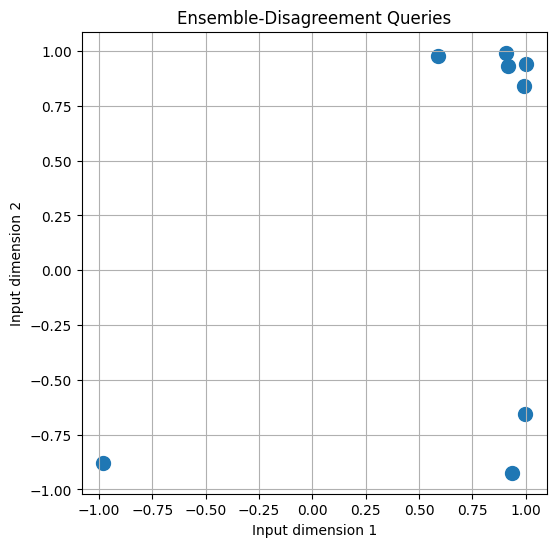

In [ ]:
# ============================================================
# CELL 4
# ENSEMBLE-DISAGREEMENT ACTIVE SELF-IDENTIFICATION
# ============================================================


class EnsembleSelfModel(nn.Module):

    def __init__(self, hidden=128):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(3, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )

        self.memory = nn.GRU(
            input_size=hidden,
            hidden_size=hidden,
            batch_first=True
        )

        self.predictor = nn.Sequential(
            nn.Linear(hidden + 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def update_memory(self, history):

        encoded_history = self.encoder(history)

        _, hidden_state = self.memory(
            encoded_history
        )

        return hidden_state[-1]

    def predict(self, state, x):

        state_x = torch.cat(
            [state, x],
            dim=-1
        )

        return self.predictor(state_x)


# ============================================================
# ENSEMBLE SETUP
# ============================================================

ensemble_size = 5

ensemble_models = [
    EnsembleSelfModel().to(device)
    for _ in range(ensemble_size)
]


ensemble_optimizers = [
    optim.Adam(
        ensemble_model.parameters(),
        lr=1e-3
    )
    for ensemble_model in ensemble_models
]


# ============================================================
# TRAINING PARAMETERS
# ============================================================

ensemble_episodes = 5000

ensemble_queries = 8

ensemble_candidates = 256

ensemble_test_size = 128


# ============================================================
# ACTIVE SELF-IDENTIFICATION
# ============================================================

for ensemble_episode in range(
    ensemble_episodes
):

    ensemble_parent = Parent().to(device)

    ensemble_history = []

    ensemble_states = [
        torch.zeros(
            1,
            128,
            device=device
        )
        for _ in range(ensemble_size)
    ]


    # --------------------------------------------------------
    # ACTIVE QUERY LOOP
    # --------------------------------------------------------

    for ensemble_step in range(
        ensemble_queries
    ):

        # ----------------------------------------------------
        # CANDIDATE QUERY SPACE
        # ----------------------------------------------------

        ensemble_candidate_x = torch.rand(
            ensemble_candidates,
            2,
            device=device
        ) * 2.0 - 1.0


        # ----------------------------------------------------
        # ENSEMBLE PREDICTIONS
        # ----------------------------------------------------

        ensemble_candidate_predictions = []


        with torch.no_grad():

            for ensemble_i in range(
                ensemble_size
            ):

                ensemble_candidate_state = \
                    ensemble_states[
                        ensemble_i
                    ].expand(
                        ensemble_candidates,
                        -1
                    )


                ensemble_candidate_prediction = \
                    ensemble_models[
                        ensemble_i
                    ].predict(
                        ensemble_candidate_state,
                        ensemble_candidate_x
                    )


                ensemble_candidate_predictions.append(
                    ensemble_candidate_prediction
                )


        ensemble_prediction_stack = torch.stack(
            ensemble_candidate_predictions,
            dim=0
        )


        # ----------------------------------------------------
        # DISAGREEMENT
        # ----------------------------------------------------

        ensemble_disagreement = torch.var(
            ensemble_prediction_stack,
            dim=0
        ).squeeze(-1)


        # ----------------------------------------------------
        # SELECT MOST DISAGREED QUERY
        # ----------------------------------------------------

        ensemble_query_index = torch.argmax(
            ensemble_disagreement
        )


        ensemble_query = ensemble_candidate_x[
            ensemble_query_index
        ].unsqueeze(0)


        # ----------------------------------------------------
        # ASK PARENT
        # ----------------------------------------------------

        with torch.no_grad():

            ensemble_parent_output = \
                ensemble_parent(
                    ensemble_query
                )


        # ----------------------------------------------------
        # STORE EXPERIMENT
        # ----------------------------------------------------

        ensemble_experiment = torch.cat(
            [
                ensemble_query,
                ensemble_parent_output
            ],
            dim=-1
        )


        ensemble_history.append(
            ensemble_experiment
        )


        ensemble_history_tensor = torch.stack(
            ensemble_history,
            dim=1
        )


        # ----------------------------------------------------
        # UPDATE ALL SELF-MODELS' MEMORIES
        # ----------------------------------------------------

        ensemble_states = [

            ensemble_models[
                ensemble_i
            ].update_memory(
                ensemble_history_tensor
            )

            for ensemble_i in range(
                ensemble_size
            )

        ]


    # ========================================================
    # GENERALIZATION TEST
    # ========================================================

    ensemble_test_x = torch.randn(
        ensemble_test_size,
        2,
        device=device
    )


    with torch.no_grad():

        ensemble_parent_y = \
            ensemble_parent(
                ensemble_test_x
            )


    ensemble_total_loss = 0.0


    # --------------------------------------------------------
    # TRAIN EACH SELF-MODEL
    # --------------------------------------------------------

    for ensemble_i in range(
        ensemble_size
    ):

        ensemble_test_state = \
            ensemble_states[
                ensemble_i
            ].expand(
                ensemble_test_size,
                -1
            )


        ensemble_prediction = \
            ensemble_models[
                ensemble_i
            ].predict(
                ensemble_test_state,
                ensemble_test_x
            )


        ensemble_loss = torch.mean(
            (
                ensemble_prediction
                - ensemble_parent_y
            ) ** 2
        )


        ensemble_optimizers[
            ensemble_i
        ].zero_grad()


        ensemble_loss.backward()


        ensemble_optimizers[
            ensemble_i
        ].step()


        ensemble_total_loss += \
            ensemble_loss.item()


    if ensemble_episode % 500 == 0:

        print(
            f"Episode {ensemble_episode} | "
            f"Ensemble mean loss: "
            f"{ensemble_total_loss / ensemble_size:.8f}"
        )


print("\nCell 4 training finished.")


# ============================================================
# QUERY INSPECTION
# ============================================================

ensemble_inspection_parent = Parent().to(device)

ensemble_inspection_history = []

ensemble_inspection_states = [

    torch.zeros(
        1,
        128,
        device=device
    )

    for _ in range(ensemble_size)

]


ensemble_inspection_queries = []

ensemble_inspection_disagreements = []


for ensemble_inspection_step in range(
    ensemble_queries
):

    ensemble_inspection_candidate_x = torch.rand(
        ensemble_candidates,
        2,
        device=device
    ) * 2.0 - 1.0


    ensemble_inspection_predictions = []


    with torch.no_grad():

        for ensemble_i in range(
            ensemble_size
        ):

            ensemble_inspection_state = \
                ensemble_inspection_states[
                    ensemble_i
                ].expand(
                    ensemble_candidates,
                    -1
                )


            ensemble_inspection_prediction = \
                ensemble_models[
                    ensemble_i
                ].predict(
                    ensemble_inspection_state,
                    ensemble_inspection_candidate_x
                )


            ensemble_inspection_predictions.append(
                ensemble_inspection_prediction
            )


    ensemble_inspection_stack = torch.stack(
        ensemble_inspection_predictions,
        dim=0
    )


    ensemble_inspection_disagreement = torch.var(
        ensemble_inspection_stack,
        dim=0
    ).squeeze(-1)


    ensemble_inspection_index = torch.argmax(
        ensemble_inspection_disagreement
    )


    ensemble_inspection_query = \
        ensemble_inspection_candidate_x[
            ensemble_inspection_index
        ].unsqueeze(0)


    ensemble_inspection_disagreement_value = \
        ensemble_inspection_disagreement[
            ensemble_inspection_index
        ].item()


    with torch.no_grad():

        ensemble_inspection_output = \
            ensemble_inspection_parent(
                ensemble_inspection_query
            )


    ensemble_inspection_experiment = torch.cat(
        [
            ensemble_inspection_query,
            ensemble_inspection_output
        ],
        dim=-1
    )


    ensemble_inspection_history.append(
        ensemble_inspection_experiment
    )


    ensemble_inspection_history_tensor = \
        torch.stack(
            ensemble_inspection_history,
            dim=1
        )


    ensemble_inspection_states = [

        ensemble_models[
            ensemble_i
        ].update_memory(
            ensemble_inspection_history_tensor
        )

        for ensemble_i in range(
            ensemble_size
        )

    ]


    ensemble_inspection_queries.append(
        ensemble_inspection_query.squeeze().cpu()
    )


    ensemble_inspection_disagreements.append(
        ensemble_inspection_disagreement_value
    )


ensemble_inspection_queries = torch.stack(
    ensemble_inspection_queries
)


print("\nEnsemble-disagreement queries:")


for ensemble_i, ensemble_query in enumerate(
    ensemble_inspection_queries
):

    print(
        f"Query {ensemble_i + 1}: "
        f"["
        f"{ensemble_query[0].item():.4f}, "
        f"{ensemble_query[1].item():.4f}"
        f"] | "
        f"Disagreement: "
        f"{ensemble_inspection_disagreements[ensemble_i]:.8f}"
    )


# ============================================================
# FINAL ENSEMBLE TEST
# ============================================================

cell4_test_x = torch.randn(
    10000,
    2,
    device=device
)


with torch.no_grad():

    cell4_parent_y = \
        ensemble_inspection_parent(
            cell4_test_x
        )


cell4_ensemble_predictions = []


with torch.no_grad():

    for ensemble_i in range(
        ensemble_size
    ):

        cell4_state = \
            ensemble_inspection_states[
                ensemble_i
            ].expand(
                10000,
                -1
            )


        cell4_prediction = \
            ensemble_models[
                ensemble_i
            ].predict(
                cell4_state,
                cell4_test_x
            )


        cell4_ensemble_predictions.append(
            cell4_prediction
        )


cell4_prediction_stack = torch.stack(
    cell4_ensemble_predictions,
    dim=0
)


cell4_ensemble_mean = torch.mean(
    cell4_prediction_stack,
    dim=0
)


cell4_mse = torch.mean(
    (
        cell4_parent_y
        - cell4_ensemble_mean
    ) ** 2
).item()


cell4_final_disagreement = torch.mean(
    torch.var(
        cell4_prediction_stack,
        dim=0
    )
).item()


print(
    "\nCell 4 Parent vs Ensemble MSE:",
    cell4_mse
)


print(
    "Cell 4 Mean Ensemble Disagreement:",
    cell4_final_disagreement
)


# ============================================================
# QUERY VISUALIZATION
# ============================================================

plt.figure(figsize=(6, 6))


plt.scatter(
    ensemble_inspection_queries[:, 0],
    ensemble_inspection_queries[:, 1],
    s=100
)


plt.xlabel("Input dimension 1")

plt.ylabel("Input dimension 2")


plt.title(
    "Ensemble-Disagreement Queries"
)


plt.grid()

plt.show()

Disagreement queries | mean MSE: 0.049715277720242736 | std: 0.042772554929078804
Random queries       | mean MSE: 0.05407842543441802 | std: 0.03260377834058584
Active better in 59 of 100 parents


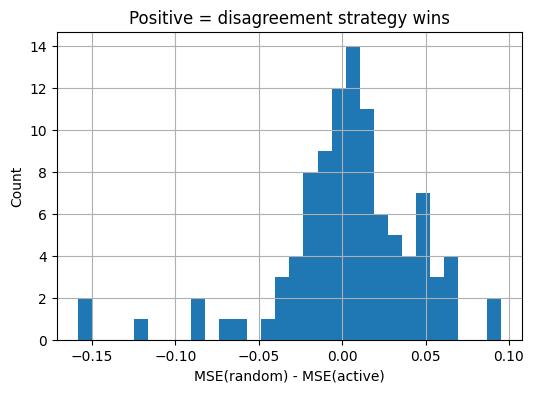

In [ ]:
# ============================================================
# CELL 5
# CONTROL EXPERIMENT
# DISAGREEMENT-DRIVEN vs RANDOM QUERIES
# Ayni egitilmis ensemble, ayni parentlar, iki sorgu stratejisi
# ============================================================

cell5_n_parents = 100

cell5_n_test = 2000

cell5_results_active = []

cell5_results_random = []


def cell5_run_queries(cell5_parent, cell5_use_disagreement):

    cell5_history = []

    cell5_states = [
        torch.zeros(1, 128, device=device)
        for _ in range(ensemble_size)
    ]

    for cell5_step in range(ensemble_queries):

        cell5_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell5_use_disagreement:

            with torch.no_grad():

                cell5_preds = torch.stack(
                    [
                        ensemble_models[i].predict(
                            cell5_states[i].expand(
                                ensemble_candidates, -1
                            ),
                            cell5_cand
                        )
                        for i in range(ensemble_size)
                    ],
                    dim=0
                )

            cell5_dis = torch.var(
                cell5_preds, dim=0
            ).squeeze(-1)

            cell5_query = cell5_cand[
                torch.argmax(cell5_dis)
            ].unsqueeze(0)

        else:

            cell5_query = cell5_cand[0].unsqueeze(0)

        with torch.no_grad():

            cell5_y = cell5_parent(cell5_query)

        cell5_history.append(
            torch.cat([cell5_query, cell5_y], dim=-1)
        )

        cell5_ht = torch.stack(cell5_history, dim=1)

        cell5_states = [
            ensemble_models[i].update_memory(cell5_ht)
            for i in range(ensemble_size)
        ]

    return cell5_states


for cell5_p in range(cell5_n_parents):

    torch.manual_seed(10000 + cell5_p)

    cell5_parent = Parent().to(device)

    cell5_x_test = torch.randn(
        cell5_n_test, 2, device=device
    )

    with torch.no_grad():

        cell5_y_parent = cell5_parent(cell5_x_test)

    for cell5_mode, cell5_bucket in [
        (True, cell5_results_active),
        (False, cell5_results_random)
    ]:

        cell5_states = cell5_run_queries(
            cell5_parent, cell5_mode
        )

        with torch.no_grad():

            cell5_preds = torch.stack(
                [
                    ensemble_models[i].predict(
                        cell5_states[i].expand(
                            cell5_n_test, -1
                        ),
                        cell5_x_test
                    )
                    for i in range(ensemble_size)
                ],
                dim=0
            )

        cell5_mean = torch.mean(cell5_preds, dim=0)

        cell5_mse = torch.mean(
            (cell5_y_parent - cell5_mean) ** 2
        ).item()

        cell5_bucket.append(cell5_mse)


import numpy as np

cell5_active = np.array(cell5_results_active)

cell5_random = np.array(cell5_results_random)

print("Disagreement queries | mean MSE:",
      cell5_active.mean(),
      "| std:", cell5_active.std())

print("Random queries       | mean MSE:",
      cell5_random.mean(),
      "| std:", cell5_random.std())

print("Active better in",
      int((cell5_active < cell5_random).sum()),
      "of", cell5_n_parents, "parents")

plt.figure(figsize=(6, 4))

plt.hist(cell5_random - cell5_active,
         bins=30)

plt.xlabel("MSE(random) - MSE(active)")

plt.ylabel("Count")

plt.title("Positive = disagreement strategy wins")

plt.grid()

plt.show()


Child episode 0 | Loss vs self-model: 0.00462990
Child episode 1000 | Loss vs self-model: 0.00000055
Child episode 2000 | Loss vs self-model: 0.00000025
Child episode 3000 | Loss vs self-model: 0.00000040
Child episode 4000 | Loss vs self-model: 0.00000020

Child vs Parent MSE inside [-1,1]: 0.012087471783161163
Parent output variance inside [-1,1]: 0.007844742387533188
Relative error inside: 1.5408373132010673

Child vs Parent MSE extrapolation: 0.06193307787179947


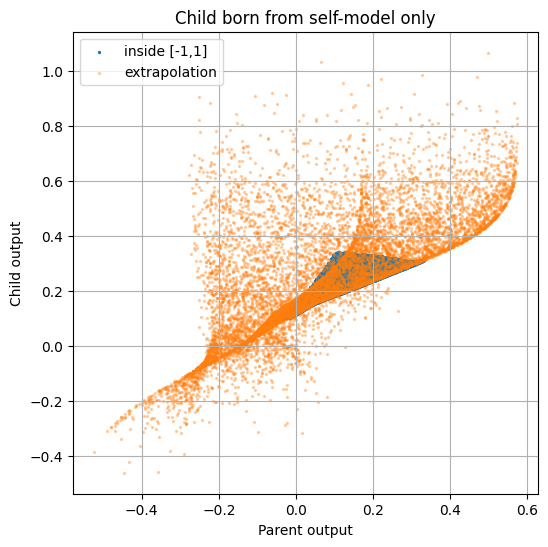

In [ ]:
# ============================================================
# CELL 6
# CHILD BIRTH
# Parent -> aktif deneylerle ensemble self-model -> Child
# Child mimarisi parenttan farkli, parenti hic gormuyor
# ============================================================

torch.manual_seed(777)

cell6_parent = Parent().to(device)

for cell6_p in cell6_parent.parameters():
    cell6_p.requires_grad = False


# --------------------------------------------------------
# 1. Aktif sorgularla self-model durumunu olustur
# --------------------------------------------------------

cell6_history = []

cell6_states = [
    torch.zeros(1, 128, device=device)
    for _ in range(ensemble_size)
]

for cell6_step in range(ensemble_queries):

    cell6_cand = torch.rand(
        ensemble_candidates, 2, device=device
    ) * 2.0 - 1.0

    with torch.no_grad():

        cell6_preds = torch.stack(
            [
                ensemble_models[i].predict(
                    cell6_states[i].expand(
                        ensemble_candidates, -1
                    ),
                    cell6_cand
                )
                for i in range(ensemble_size)
            ],
            dim=0
        )

    cell6_dis = torch.var(
        cell6_preds, dim=0
    ).squeeze(-1)

    cell6_query = cell6_cand[
        torch.argmax(cell6_dis)
    ].unsqueeze(0)

    with torch.no_grad():

        cell6_y = cell6_parent(cell6_query)

    cell6_history.append(
        torch.cat([cell6_query, cell6_y], dim=-1)
    )

    cell6_ht = torch.stack(cell6_history, dim=1)

    cell6_states = [
        ensemble_models[i].update_memory(cell6_ht)
        for i in range(ensemble_size)
    ]


# --------------------------------------------------------
# 2. Child, yalnizca self-model ciktisindan egitiliyor
#    Parent'a bir daha HIC sorulmuyor
# --------------------------------------------------------

cell6_child = Child().to(device)

cell6_child_opt = optim.Adam(
    cell6_child.parameters(), lr=1e-3
)

for cell6_ep in range(5000):

    cell6_x = torch.rand(
        256, 2, device=device
    ) * 2.0 - 1.0

    with torch.no_grad():

        cell6_teacher = torch.mean(
            torch.stack(
                [
                    ensemble_models[i].predict(
                        cell6_states[i].expand(256, -1),
                        cell6_x
                    )
                    for i in range(ensemble_size)
                ],
                dim=0
            ),
            dim=0
        )

    cell6_pred = cell6_child(cell6_x)

    cell6_loss = torch.mean(
        (cell6_pred - cell6_teacher) ** 2
    )

    cell6_child_opt.zero_grad()

    cell6_loss.backward()

    cell6_child_opt.step()

    if cell6_ep % 1000 == 0:

        print(
            f"Child episode {cell6_ep} | "
            f"Loss vs self-model: {cell6_loss.item():.8f}"
        )


# --------------------------------------------------------
# 3. Test: Child, parenti hic gormeden onu taklit etti mi
#    Iki bolge: sorgu bolgesi [-1,1] ve extrapolasyon
# --------------------------------------------------------

cell6_x_in = torch.rand(
    10000, 2, device=device
) * 2.0 - 1.0

cell6_x_out = torch.randn(
    10000, 2, device=device
) * 2.0

with torch.no_grad():

    cell6_in_parent = cell6_parent(cell6_x_in)

    cell6_in_child = cell6_child(cell6_x_in)

    cell6_out_parent = cell6_parent(cell6_x_out)

    cell6_out_child = cell6_child(cell6_x_out)

cell6_mse_in = torch.mean(
    (cell6_in_parent - cell6_in_child) ** 2
).item()

cell6_mse_out = torch.mean(
    (cell6_out_parent - cell6_out_child) ** 2
).item()

cell6_var_in = torch.var(cell6_in_parent).item()

print("\nChild vs Parent MSE inside [-1,1]:",
      cell6_mse_in)

print("Parent output variance inside [-1,1]:",
      cell6_var_in)

print("Relative error inside:",
      cell6_mse_in / cell6_var_in)

print("\nChild vs Parent MSE extrapolation:",
      cell6_mse_out)

plt.figure(figsize=(6, 6))

plt.scatter(
    cell6_in_parent.cpu(),
    cell6_in_child.cpu(),
    s=2, label="inside [-1,1]"
)

plt.scatter(
    cell6_out_parent.cpu(),
    cell6_out_child.cpu(),
    s=2, alpha=0.3, label="extrapolation"
)

plt.xlabel("Parent output")

plt.ylabel("Child output")

plt.title("Child born from self-model only")

plt.legend()

plt.grid()

plt.show()


In [ ]:
# ============================================================
# CELL 7
# IDENTIFICATION SHOWDOWN
# Ayni 8 gozlem: ensemble meta-learner vs dogrudan fit vs ortalama
# Test, sorgu bolgesiyle ayni: uniform [-1,1]^2
# ============================================================

cell7_n_parents = 50

cell7_n_test = 2000

cell7_rel_ensemble = []

cell7_rel_directfit = []

cell7_rel_meanpred = []


def cell7_collect(cell7_parent):

    cell7_history = []

    cell7_states = [
        torch.zeros(1, 128, device=device)
        for _ in range(ensemble_size)
    ]

    for cell7_step in range(ensemble_queries):

        cell7_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell7_preds = torch.stack(
                [
                    ensemble_models[i].predict(
                        cell7_states[i].expand(
                            ensemble_candidates, -1
                        ),
                        cell7_cand
                    )
                    for i in range(ensemble_size)
                ],
                dim=0
            )

        cell7_dis = torch.var(
            cell7_preds, dim=0
        ).squeeze(-1)

        cell7_query = cell7_cand[
            torch.argmax(cell7_dis)
        ].unsqueeze(0)

        with torch.no_grad():

            cell7_y = cell7_parent(cell7_query)

        cell7_history.append(
            torch.cat([cell7_query, cell7_y], dim=-1)
        )

        cell7_ht = torch.stack(cell7_history, dim=1)

        cell7_states = [
            ensemble_models[i].update_memory(cell7_ht)
            for i in range(ensemble_size)
        ]

    cell7_obs = torch.cat(cell7_history, dim=0)

    return cell7_states, cell7_obs


for cell7_p in range(cell7_n_parents):

    torch.manual_seed(20000 + cell7_p)

    cell7_parent = Parent().to(device)

    cell7_states, cell7_obs = cell7_collect(cell7_parent)

    cell7_obs_x = cell7_obs[:, :2]

    cell7_obs_y = cell7_obs[:, 2:3]

    cell7_x_test = torch.rand(
        cell7_n_test, 2, device=device
    ) * 2.0 - 1.0

    with torch.no_grad():

        cell7_y_parent = cell7_parent(cell7_x_test)

    cell7_var = torch.var(cell7_y_parent).item() + 1e-8

    # 1. Ensemble meta-learner

    with torch.no_grad():

        cell7_ens = torch.mean(
            torch.stack(
                [
                    ensemble_models[i].predict(
                        cell7_states[i].expand(
                            cell7_n_test, -1
                        ),
                        cell7_x_test
                    )
                    for i in range(ensemble_size)
                ],
                dim=0
            ),
            dim=0
        )

    cell7_rel_ensemble.append(
        torch.mean(
            (cell7_y_parent - cell7_ens) ** 2
        ).item() / cell7_var
    )

    # 2. Dogrudan fit: 8 noktaya kucuk ag

    cell7_fit = nn.Sequential(
        nn.Linear(2, 32), nn.ReLU(),
        nn.Linear(32, 32), nn.ReLU(),
        nn.Linear(32, 1)
    ).to(device)

    cell7_fit_opt = optim.Adam(
        cell7_fit.parameters(), lr=1e-2
    )

    for cell7_it in range(500):

        cell7_fit_loss = torch.mean(
            (cell7_fit(cell7_obs_x) - cell7_obs_y) ** 2
        )

        cell7_fit_opt.zero_grad()

        cell7_fit_loss.backward()

        cell7_fit_opt.step()

    with torch.no_grad():

        cell7_direct = cell7_fit(cell7_x_test)

    cell7_rel_directfit.append(
        torch.mean(
            (cell7_y_parent - cell7_direct) ** 2
        ).item() / cell7_var
    )

    # 3. Ortalama tahminci

    cell7_mean = torch.mean(cell7_obs_y)

    cell7_rel_meanpred.append(
        torch.mean(
            (cell7_y_parent - cell7_mean) ** 2
        ).item() / cell7_var
    )


import numpy as np

cell7_e = np.array(cell7_rel_ensemble)

cell7_d = np.array(cell7_rel_directfit)

cell7_m = np.array(cell7_rel_meanpred)

print("Relative error (1.0 = ortalamayi tahmin etmek kadar iyi)")

print(f"Ensemble meta-learner | median: {np.median(cell7_e):.4f} | mean: {cell7_e.mean():.4f}")

print(f"Direct fit 8 nokta    | median: {np.median(cell7_d):.4f} | mean: {cell7_d.mean():.4f}")

print(f"Mean predictor        | median: {np.median(cell7_m):.4f} | mean: {cell7_m.mean():.4f}")

print(f"\nEnsemble < DirectFit: {int((cell7_e < cell7_d).sum())} / {cell7_n_parents}")

print(f"Ensemble < 1.0 (bilgi tasiyor): {int((cell7_e < 1.0).sum())} / {cell7_n_parents}")

Relative error (1.0 = ortalamayi tahmin etmek kadar iyi)
Ensemble meta-learner | median: 2.1098 | mean: 3.1479
Direct fit 8 nokta    | median: 0.1605 | mean: 0.6632
Mean predictor        | median: 1.2484 | mean: 1.6944

Ensemble < DirectFit: 8 / 50
Ensemble < 1.0 (bilgi tasiyor): 19 / 50


In [ ]:
# ============================================================
# CELL 8
# DIRECT-FIT ENSEMBLE SELF-MODEL
# Her gozlemden sonra yeniden egitilen surrogate ensemble
# Aktif vs rastgele sorgu + child dogumu
# ============================================================

cell8_n_parents = 50

cell8_n_test = 2000

cell8_members = 5

cell8_refit_iters = 300


def cell8_make_member():

    return nn.Sequential(
        nn.Linear(2, 32), nn.ReLU(),
        nn.Linear(32, 32), nn.ReLU(),
        nn.Linear(32, 1)
    ).to(device)


def cell8_refit(cell8_nets, cell8_opts, cell8_x, cell8_y):

    for cell8_net, cell8_opt in zip(cell8_nets, cell8_opts):

        for cell8_it in range(cell8_refit_iters):

            cell8_loss = torch.mean(
                (cell8_net(cell8_x) - cell8_y) ** 2
            )

            cell8_opt.zero_grad()

            cell8_loss.backward()

            cell8_opt.step()


def cell8_identify(cell8_parent, cell8_active):

    cell8_nets = [cell8_make_member() for _ in range(cell8_members)]

    cell8_opts = [
        optim.Adam(cell8_net.parameters(), lr=1e-2)
        for cell8_net in cell8_nets
    ]

    cell8_obs_x = torch.zeros(0, 2, device=device)

    cell8_obs_y = torch.zeros(0, 1, device=device)

    for cell8_step in range(ensemble_queries):

        cell8_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell8_active and cell8_step > 0:

            with torch.no_grad():

                cell8_preds = torch.stack(
                    [cell8_net(cell8_cand) for cell8_net in cell8_nets],
                    dim=0
                )

            cell8_dis = torch.var(cell8_preds, dim=0).squeeze(-1)

            cell8_query = cell8_cand[
                torch.argmax(cell8_dis)
            ].unsqueeze(0)

        else:

            cell8_query = cell8_cand[0].unsqueeze(0)

        with torch.no_grad():

            cell8_y = cell8_parent(cell8_query)

        cell8_obs_x = torch.cat([cell8_obs_x, cell8_query], dim=0)

        cell8_obs_y = torch.cat([cell8_obs_y, cell8_y], dim=0)

        cell8_refit(cell8_nets, cell8_opts, cell8_obs_x, cell8_obs_y)

    return cell8_nets


cell8_rel_active = []

cell8_rel_random = []


for cell8_p in range(cell8_n_parents):

    torch.manual_seed(30000 + cell8_p)

    cell8_parent = Parent().to(device)

    cell8_x_test = torch.rand(
        cell8_n_test, 2, device=device
    ) * 2.0 - 1.0

    with torch.no_grad():

        cell8_y_parent = cell8_parent(cell8_x_test)

    cell8_var = torch.var(cell8_y_parent).item() + 1e-8

    for cell8_mode, cell8_bucket in [
        (True, cell8_rel_active),
        (False, cell8_rel_random)
    ]:

        cell8_nets = cell8_identify(cell8_parent, cell8_mode)

        with torch.no_grad():

            cell8_mean = torch.mean(
                torch.stack(
                    [cell8_net(cell8_x_test) for cell8_net in cell8_nets],
                    dim=0
                ),
                dim=0
            )

        cell8_bucket.append(
            torch.mean(
                (cell8_y_parent - cell8_mean) ** 2
            ).item() / cell8_var
        )


import numpy as np

cell8_a = np.array(cell8_rel_active)

cell8_r = np.array(cell8_rel_random)

print("Relative error, direct-fit ensemble self-model")

print(f"Active queries | median: {np.median(cell8_a):.4f} | mean: {cell8_a.mean():.4f}")

print(f"Random queries | median: {np.median(cell8_r):.4f} | mean: {cell8_r.mean():.4f}")

print(f"Active better: {int((cell8_a < cell8_r).sum())} / {cell8_n_parents}")


# ============================================================
# CHILD BIRTH FROM DIRECT-FIT SELF-MODEL
# Son parent uzerinde: 8 aktif gozlem -> ensemble -> child
# ============================================================

torch.manual_seed(777)

cell8_birth_parent = Parent().to(device)

cell8_birth_nets = cell8_identify(cell8_birth_parent, True)

cell8_child = Child().to(device)

cell8_child_opt = optim.Adam(cell8_child.parameters(), lr=1e-3)

for cell8_ep in range(3000):

    cell8_x = torch.rand(256, 2, device=device) * 2.0 - 1.0

    with torch.no_grad():

        cell8_teacher = torch.mean(
            torch.stack(
                [cell8_net(cell8_x) for cell8_net in cell8_birth_nets],
                dim=0
            ),
            dim=0
        )

    cell8_loss = torch.mean(
        (cell8_child(cell8_x) - cell8_teacher) ** 2
    )

    cell8_child_opt.zero_grad()

    cell8_loss.backward()

    cell8_child_opt.step()


cell8_bx = torch.rand(10000, 2, device=device) * 2.0 - 1.0

with torch.no_grad():

    cell8_bp = cell8_birth_parent(cell8_bx)

    cell8_bc = cell8_child(cell8_bx)

cell8_child_rel = (
    torch.mean((cell8_bp - cell8_bc) ** 2).item()
    / (torch.var(cell8_bp).item() + 1e-8)
)

print(f"\nChild relative error inside [-1,1]: {cell8_child_rel:.4f}")

Relative error, direct-fit ensemble self-model
Active queries | median: 0.0114 | mean: 0.0176
Random queries | median: 0.0305 | mean: 0.0440
Active better: 38 / 50

Child relative error inside [-1,1]: 0.0498


Lineage 0 done
Lineage 5 done
Lineage 10 done
Lineage 15 done

Gen | rel.err vs ANCESTOR (median) | rel.err vs PARENT (median)
  1 | 0.0110 | 0.0110
  2 | 0.0226 | 0.0108
  3 | 0.0349 | 0.0097


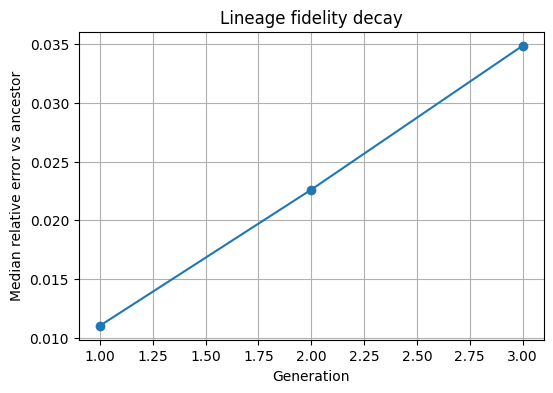

In [ ]:
# ============================================================
# CELL 9
# LINEAGE: PARENT -> CHILD -> GRANDCHILD -> ...
# Her nesil, bir onceki neslin 8 aktif gozlemle
# kurulan self-modelinden doguyor
# Olcum: ataya ve dogrudan ebeveyne gore relative error
# ============================================================

cell9_n_lineages = 20

cell9_n_generations = 3

cell9_n_test = 5000


def cell9_birth(cell9_source):

    # 8 aktif gozlemle self-model kur (Cell 8 mekanizmasi)

    cell9_nets = cell8_identify(cell9_source, True)

    # Child dogur: yalnizca self-modelden damitma

    cell9_new = Child().to(device)

    cell9_opt = optim.Adam(cell9_new.parameters(), lr=1e-3)

    for cell9_ep in range(3000):

        cell9_x = torch.rand(256, 2, device=device) * 2.0 - 1.0

        with torch.no_grad():

            cell9_teacher = torch.mean(
                torch.stack(
                    [cell9_net(cell9_x) for cell9_net in cell9_nets],
                    dim=0
                ),
                dim=0
            )

        cell9_loss = torch.mean(
            (cell9_new(cell9_x) - cell9_teacher) ** 2
        )

        cell9_opt.zero_grad()

        cell9_loss.backward()

        cell9_opt.step()

    for cell9_p in cell9_new.parameters():

        cell9_p.requires_grad = False

    return cell9_new


cell9_err_ancestor = [[] for _ in range(cell9_n_generations)]

cell9_err_parent = [[] for _ in range(cell9_n_generations)]


for cell9_l in range(cell9_n_lineages):

    torch.manual_seed(40000 + cell9_l)

    cell9_ancestor = Parent().to(device)

    for cell9_pp in cell9_ancestor.parameters():

        cell9_pp.requires_grad = False

    cell9_x_test = torch.rand(
        cell9_n_test, 2, device=device
    ) * 2.0 - 1.0

    with torch.no_grad():

        cell9_y_anc = cell9_ancestor(cell9_x_test)

    cell9_var_anc = torch.var(cell9_y_anc).item() + 1e-8

    cell9_current = cell9_ancestor

    for cell9_g in range(cell9_n_generations):

        cell9_next = cell9_birth(cell9_current)

        with torch.no_grad():

            cell9_y_next = cell9_next(cell9_x_test)

            cell9_y_cur = cell9_current(cell9_x_test)

        cell9_err_ancestor[cell9_g].append(
            torch.mean(
                (cell9_y_anc - cell9_y_next) ** 2
            ).item() / cell9_var_anc
        )

        cell9_var_cur = torch.var(cell9_y_cur).item() + 1e-8

        cell9_err_parent[cell9_g].append(
            torch.mean(
                (cell9_y_cur - cell9_y_next) ** 2
            ).item() / cell9_var_cur
        )

        cell9_current = cell9_next

    if cell9_l % 5 == 0:

        print(f"Lineage {cell9_l} done")


import numpy as np

print("\nGen | rel.err vs ANCESTOR (median) | rel.err vs PARENT (median)")

for cell9_g in range(cell9_n_generations):

    cell9_ea = np.median(np.array(cell9_err_ancestor[cell9_g]))

    cell9_ep2 = np.median(np.array(cell9_err_parent[cell9_g]))

    print(f"  {cell9_g + 1} | {cell9_ea:.4f} | {cell9_ep2:.4f}")


plt.figure(figsize=(6, 4))

cell9_meds = [
    np.median(np.array(cell9_err_ancestor[g]))
    for g in range(cell9_n_generations)
]

plt.plot(
    range(1, cell9_n_generations + 1),
    cell9_meds,
    marker="o"
)

plt.xlabel("Generation")

plt.ylabel("Median relative error vs ancestor")

plt.title("Lineage fidelity decay")

plt.grid()

plt.show()

In [ ]:
# ============================================================
# CELL 10
# OZ DNA vs EVLATLIK
# Ayni atadan iki soy: tanh ikiz (parent mimarisi)
# ve ReLU evlatlik. Icerde ve extrapolasyonda kiyas.
# ============================================================

class TanhTwin(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )

    def forward(self, x):

        return self.net(x)


cell10_n_lineages = 15

cell10_n_generations = 3

cell10_n_test = 5000


def cell10_birth(cell10_source, cell10_arch):

    cell10_nets = cell8_identify(cell10_source, True)

    cell10_new = cell10_arch().to(device)

    cell10_opt = optim.Adam(
        cell10_new.parameters(), lr=1e-3
    )

    for cell10_ep in range(3000):

        cell10_x = torch.rand(
            256, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell10_teacher = torch.mean(
                torch.stack(
                    [
                        cell10_net(cell10_x)
                        for cell10_net in cell10_nets
                    ],
                    dim=0
                ),
                dim=0
            )

        cell10_loss = torch.mean(
            (cell10_new(cell10_x) - cell10_teacher) ** 2
        )

        cell10_opt.zero_grad()

        cell10_loss.backward()

        cell10_opt.step()

    for cell10_p in cell10_new.parameters():

        cell10_p.requires_grad = False

    return cell10_new


cell10_in_twin = [[] for _ in range(cell10_n_generations)]

cell10_in_adopt = [[] for _ in range(cell10_n_generations)]

cell10_ex_twin = [[] for _ in range(cell10_n_generations)]

cell10_ex_adopt = [[] for _ in range(cell10_n_generations)]


for cell10_l in range(cell10_n_lineages):

    torch.manual_seed(50000 + cell10_l)

    cell10_anc = Parent().to(device)

    for cell10_pp in cell10_anc.parameters():

        cell10_pp.requires_grad = False

    cell10_x_in = torch.rand(
        cell10_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell10_x_ex = torch.randn(
        cell10_n_test, 2, device=device
    ) * 2.0

    with torch.no_grad():

        cell10_y_in = cell10_anc(cell10_x_in)

        cell10_y_ex = cell10_anc(cell10_x_ex)

    cell10_v_in = torch.var(cell10_y_in).item() + 1e-8

    cell10_v_ex = torch.var(cell10_y_ex).item() + 1e-8

    for cell10_arch, cell10_bin, cell10_bex in [
        (TanhTwin, cell10_in_twin, cell10_ex_twin),
        (Child, cell10_in_adopt, cell10_ex_adopt)
    ]:

        cell10_cur = cell10_anc

        for cell10_g in range(cell10_n_generations):

            cell10_next = cell10_birth(
                cell10_cur, cell10_arch
            )

            with torch.no_grad():

                cell10_p_in = cell10_next(cell10_x_in)

                cell10_p_ex = cell10_next(cell10_x_ex)

            cell10_bin[cell10_g].append(
                torch.mean(
                    (cell10_y_in - cell10_p_in) ** 2
                ).item() / cell10_v_in
            )

            cell10_bex[cell10_g].append(
                torch.mean(
                    (cell10_y_ex - cell10_p_ex) ** 2
                ).item() / cell10_v_ex
            )

            cell10_cur = cell10_next

    if cell10_l % 5 == 0:

        print(f"Lineage {cell10_l} done")


import numpy as np

print("\nINSIDE [-1,1] median rel.err vs ancestor")

print("Gen | Tanh twin | ReLU adoptee")

for cell10_g in range(cell10_n_generations):

    print(
        f"  {cell10_g + 1} | "
        f"{np.median(cell10_in_twin[cell10_g]):.4f} | "
        f"{np.median(cell10_in_adopt[cell10_g]):.4f}"
    )

print("\nEXTRAPOLATION (randn*2) median rel.err vs ancestor")

print("Gen | Tanh twin | ReLU adoptee")

for cell10_g in range(cell10_n_generations):

    print(
        f"  {cell10_g + 1} | "
        f"{np.median(cell10_ex_twin[cell10_g]):.4f} | "
        f"{np.median(cell10_ex_adopt[cell10_g]):.4f}"
    )

Lineage 0 done
Lineage 5 done
Lineage 10 done

INSIDE [-1,1] median rel.err vs ancestor
Gen | Tanh twin | ReLU adoptee
  1 | 0.0070 | 0.0111
  2 | 0.0292 | 0.0163
  3 | 0.0403 | 0.0316

EXTRAPOLATION (randn*2) median rel.err vs ancestor
Gen | Tanh twin | ReLU adoptee
  1 | 0.1856 | 0.3240
  2 | 0.1316 | 0.2481
  3 | 0.1560 | 0.3088


In [ ]:
# ============================================================
# CELL 10B
# GENIS TANH (kurallara uygun hibrit) ve
# GENETIK HIBRIT (yarisi babadan, yarisi rastgele esten,
# ust sinir kontrolu, kara kutu kuralini bilerek deler)
# Ayni seedler: Cell 10 tablosuyla dogrudan kiyaslanabilir
# ============================================================

class WideTanh(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.net(x)


def cell10b_genetic_init(cell10b_child, cell10b_father):

    # Yarisi babadan, yarisi rastgele esten (ayni mimari)

    cell10b_mate = type(cell10b_father)().to(device)

    with torch.no_grad():

        for cell10b_c, cell10b_f, cell10b_m in zip(
            cell10b_child.parameters(),
            cell10b_father.parameters(),
            cell10b_mate.parameters()
        ):

            cell10b_mask = (
                torch.rand_like(cell10b_f) < 0.5
            ).float()

            cell10b_c.copy_(
                cell10b_mask * cell10b_f
                + (1 - cell10b_mask) * cell10b_m
            )


cell10b_n_lineages = 15

cell10b_n_generations = 3

cell10b_n_test = 5000


def cell10b_birth(cell10b_source, cell10b_mode):

    cell10b_nets = cell8_identify(cell10b_source, True)

    if cell10b_mode == "wide":

        cell10b_new = WideTanh().to(device)

    else:

        cell10b_new = type(cell10b_source)().to(device)

        cell10b_genetic_init(cell10b_new, cell10b_source)

    cell10b_opt = optim.Adam(
        cell10b_new.parameters(), lr=1e-3
    )

    for cell10b_ep in range(3000):

        cell10b_x = torch.rand(
            256, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell10b_t = torch.mean(
                torch.stack(
                    [
                        cell10b_n(cell10b_x)
                        for cell10b_n in cell10b_nets
                    ],
                    dim=0
                ),
                dim=0
            )

        cell10b_l = torch.mean(
            (cell10b_new(cell10b_x) - cell10b_t) ** 2
        )

        cell10b_opt.zero_grad()

        cell10b_l.backward()

        cell10b_opt.step()

    for cell10b_p in cell10b_new.parameters():

        cell10b_p.requires_grad = False

    return cell10b_new


cell10b_in = {
    "wide": [[] for _ in range(cell10b_n_generations)],
    "genetic": [[] for _ in range(cell10b_n_generations)]
}

cell10b_ex = {
    "wide": [[] for _ in range(cell10b_n_generations)],
    "genetic": [[] for _ in range(cell10b_n_generations)]
}


for cell10b_l in range(cell10b_n_lineages):

    torch.manual_seed(50000 + cell10b_l)

    cell10b_anc = Parent().to(device)

    for cell10b_pp in cell10b_anc.parameters():

        cell10b_pp.requires_grad = False

    cell10b_x_in = torch.rand(
        cell10b_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell10b_x_ex = torch.randn(
        cell10b_n_test, 2, device=device
    ) * 2.0

    with torch.no_grad():

        cell10b_y_in = cell10b_anc(cell10b_x_in)

        cell10b_y_ex = cell10b_anc(cell10b_x_ex)

    cell10b_v_in = torch.var(cell10b_y_in).item() + 1e-8

    cell10b_v_ex = torch.var(cell10b_y_ex).item() + 1e-8

    for cell10b_mode in ["wide", "genetic"]:

        cell10b_cur = cell10b_anc

        for cell10b_g in range(cell10b_n_generations):

            cell10b_next = cell10b_birth(
                cell10b_cur, cell10b_mode
            )

            with torch.no_grad():

                cell10b_pi = cell10b_next(cell10b_x_in)

                cell10b_pe = cell10b_next(cell10b_x_ex)

            cell10b_in[cell10b_mode][cell10b_g].append(
                torch.mean(
                    (cell10b_y_in - cell10b_pi) ** 2
                ).item() / cell10b_v_in
            )

            cell10b_ex[cell10b_mode][cell10b_g].append(
                torch.mean(
                    (cell10b_y_ex - cell10b_pe) ** 2
                ).item() / cell10b_v_ex
            )

            cell10b_cur = cell10b_next

    if cell10b_l % 5 == 0:

        print(f"Lineage {cell10b_l} done")


import numpy as np

print("\nINSIDE [-1,1] median rel.err vs ancestor")

print("Gen | WideTanh | GeneticHybrid")

for cell10b_g in range(cell10b_n_generations):

    print(
        f"  {cell10b_g + 1} | "
        f"{np.median(cell10b_in['wide'][cell10b_g]):.4f} | "
        f"{np.median(cell10b_in['genetic'][cell10b_g]):.4f}"
    )

print("\nEXTRAPOLATION median rel.err vs ancestor")

print("Gen | WideTanh | GeneticHybrid")

for cell10b_g in range(cell10b_n_generations):

    print(
        f"  {cell10b_g + 1} | "
        f"{np.median(cell10b_ex['wide'][cell10b_g]):.4f} | "
        f"{np.median(cell10b_ex['genetic'][cell10b_g]):.4f}"
    )

Lineage 0 done
Lineage 5 done
Lineage 10 done

INSIDE [-1,1] median rel.err vs ancestor
Gen | WideTanh | GeneticHybrid
  1 | 0.0071 | 0.0084
  2 | 0.0214 | 0.0316
  3 | 0.0369 | 0.0456

EXTRAPOLATION median rel.err vs ancestor
Gen | WideTanh | GeneticHybrid
  1 | 0.0807 | 0.1291
  2 | 0.1527 | 0.1249
  3 | 0.1249 | 0.1184


In [ ]:
# ============================================================
# CELL 11
# EMBEDDED OBSERVER: tek organizma, govde + oz-gozlem organi
# Privileged access testi: iceriden bakmak vs disaridan bakmak
# Ayni 8 sorgu butcesi, sonra iki self-modelden iki child
# Child mimarisi: WideTanh (Cell 10b kazanani)
# ============================================================

class Organism(nn.Module):

    def __init__(self, n_self_heads=5):

        super().__init__()

        self.trunk = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU()
        )

        self.task_head = nn.Linear(32, 1)

        self.self_heads = nn.ModuleList(
            [nn.Linear(32, 1) for _ in range(n_self_heads)]
        )

    def body(self, x):

        return self.task_head(self.trunk(x))

    def introspect_all(self, x):

        cell11_z = self.trunk(x)

        return torch.stack(
            [h(cell11_z) for h in self.self_heads],
            dim=0
        )


class BodyWrapper(nn.Module):

    def __init__(self, organism):

        super().__init__()

        self.organism = organism

    def forward(self, x):

        return self.organism.body(x)


cell11_n_organisms = 20

cell11_n_test = 5000

cell11_res_self_emb = []

cell11_res_self_ext = []

cell11_res_child_emb = []

cell11_res_child_ext = []


def cell11_train_self_heads(cell11_org):

    cell11_opt = optim.Adam(
        cell11_org.self_heads.parameters(), lr=1e-2
    )

    cell11_obs_x = torch.zeros(0, 2, device=device)

    cell11_obs_y = torch.zeros(0, 1, device=device)

    for cell11_step in range(ensemble_queries):

        cell11_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell11_step > 0:

            with torch.no_grad():

                cell11_preds = cell11_org.introspect_all(
                    cell11_cand
                )

            cell11_dis = torch.var(
                cell11_preds, dim=0
            ).squeeze(-1)

            cell11_q = cell11_cand[
                torch.argmax(cell11_dis)
            ].unsqueeze(0)

        else:

            cell11_q = cell11_cand[0].unsqueeze(0)

        with torch.no_grad():

            cell11_y = cell11_org.body(cell11_q)

        cell11_obs_x = torch.cat(
            [cell11_obs_x, cell11_q], dim=0
        )

        cell11_obs_y = torch.cat(
            [cell11_obs_y, cell11_y], dim=0
        )

        for cell11_it in range(300):

            cell11_p = cell11_org.introspect_all(
                cell11_obs_x
            )

            cell11_loss = torch.mean(
                (cell11_p - cell11_obs_y.unsqueeze(0)) ** 2
            )

            cell11_opt.zero_grad()

            cell11_loss.backward()

            cell11_opt.step()


def cell11_distill_child(cell11_teacher_fn):

    cell11_ch = WideTanh().to(device)

    cell11_o = optim.Adam(cell11_ch.parameters(), lr=1e-3)

    for cell11_ep in range(3000):

        cell11_x = torch.rand(
            256, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell11_t = cell11_teacher_fn(cell11_x)

        cell11_l = torch.mean(
            (cell11_ch(cell11_x) - cell11_t) ** 2
        )

        cell11_o.zero_grad()

        cell11_l.backward()

        cell11_o.step()

    return cell11_ch


for cell11_i in range(cell11_n_organisms):

    torch.manual_seed(60000 + cell11_i)

    cell11_org = Organism().to(device)

    for cell11_p in cell11_org.trunk.parameters():

        cell11_p.requires_grad = False

    for cell11_p in cell11_org.task_head.parameters():

        cell11_p.requires_grad = False

    cell11_x_test = torch.rand(
        cell11_n_test, 2, device=device
    ) * 2.0 - 1.0

    with torch.no_grad():

        cell11_y_body = cell11_org.body(cell11_x_test)

    cell11_var = torch.var(cell11_y_body).item() + 1e-8

    # 1. Gomulu oz-gozlem

    cell11_train_self_heads(cell11_org)

    with torch.no_grad():

        cell11_emb = torch.mean(
            cell11_org.introspect_all(cell11_x_test),
            dim=0
        )

    cell11_res_self_emb.append(
        torch.mean(
            (cell11_y_body - cell11_emb) ** 2
        ).item() / cell11_var
    )

    # 2. Dis gozlemci, ayni butce

    cell11_wrap = BodyWrapper(cell11_org)

    cell11_ext_nets = cell8_identify(cell11_wrap, True)

    with torch.no_grad():

        cell11_ext = torch.mean(
            torch.stack(
                [n(cell11_x_test) for n in cell11_ext_nets],
                dim=0
            ),
            dim=0
        )

    cell11_res_self_ext.append(
        torch.mean(
            (cell11_y_body - cell11_ext) ** 2
        ).item() / cell11_var
    )

    # 3. Iki child dogumu

    cell11_ch_emb = cell11_distill_child(
        lambda x: torch.mean(
            cell11_org.introspect_all(x), dim=0
        )
    )

    cell11_ch_ext = cell11_distill_child(
        lambda x: torch.mean(
            torch.stack(
                [n(x) for n in cell11_ext_nets], dim=0
            ),
            dim=0
        )
    )

    with torch.no_grad():

        cell11_pe = cell11_ch_emb(cell11_x_test)

        cell11_px = cell11_ch_ext(cell11_x_test)

    cell11_res_child_emb.append(
        torch.mean(
            (cell11_y_body - cell11_pe) ** 2
        ).item() / cell11_var
    )

    cell11_res_child_ext.append(
        torch.mean(
            (cell11_y_body - cell11_px) ** 2
        ).item() / cell11_var
    )

    if cell11_i % 5 == 0:

        print(f"Organism {cell11_i} done")


import numpy as np

print("\nMedian relative error vs body")

print("Embedded self-model :",
      f"{np.median(cell11_res_self_emb):.4f}")

print("External self-model :",
      f"{np.median(cell11_res_self_ext):.4f}")

print("Child from embedded :",
      f"{np.median(cell11_res_child_emb):.4f}")

print("Child from external :",
      f"{np.median(cell11_res_child_ext):.4f}")

print("\nEmbedded better in",
      int(np.sum(np.array(cell11_res_self_emb)
                 < np.array(cell11_res_self_ext))),
      "of", cell11_n_organisms)

Organism 0 done
Organism 5 done
Organism 10 done
Organism 15 done

Median relative error vs body
Embedded self-model : 0.0599
External self-model : 0.0645
Child from embedded : 0.0598
Child from external : 0.0653

Embedded better in 13 of 20


In [ ]:
# ============================================================
# CELL 12
# BUTCE TARAMASI: iceriden bakmanin avantaji ne zaman aciliyor
# Teshis: govde 33 parametreli dogrusal bir okuma,
# gomulu gozlemci ancak >=33 gozlemde sistemi tam cozebilir
# Ek olcum: ensemble cesitliligi (disagreement collapse)
# ============================================================

cell12_budgets = [8, 16, 33, 64, 128]

cell12_n_organisms = 10

cell12_n_test = 5000

cell12_emb = {b: [] for b in cell12_budgets}

cell12_ext = {b: [] for b in cell12_budgets}

cell12_div_emb = {b: [] for b in cell12_budgets}

cell12_div_ext = {b: [] for b in cell12_budgets}


def cell12_embedded(cell12_org, cell12_budget):

    cell12_opt = optim.Adam(
        cell12_org.self_heads.parameters(), lr=1e-2
    )

    cell12_ox = torch.zeros(0, 2, device=device)

    cell12_oy = torch.zeros(0, 1, device=device)

    for cell12_s in range(cell12_budget):

        cell12_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell12_s > 0:

            with torch.no_grad():

                cell12_p = cell12_org.introspect_all(
                    cell12_cand
                )

            cell12_q = cell12_cand[
                torch.argmax(
                    torch.var(cell12_p, dim=0).squeeze(-1)
                )
            ].unsqueeze(0)

        else:

            cell12_q = cell12_cand[0].unsqueeze(0)

        with torch.no_grad():

            cell12_y = cell12_org.body(cell12_q)

        cell12_ox = torch.cat([cell12_ox, cell12_q], dim=0)

        cell12_oy = torch.cat([cell12_oy, cell12_y], dim=0)

        for cell12_it in range(300):

            cell12_pr = cell12_org.introspect_all(cell12_ox)

            cell12_l = torch.mean(
                (cell12_pr - cell12_oy.unsqueeze(0)) ** 2
            )

            cell12_opt.zero_grad()

            cell12_l.backward()

            cell12_opt.step()


def cell12_external(cell12_parent, cell12_budget):

    cell12_nets = [
        nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 1)
        ).to(device)
        for _ in range(5)
    ]

    cell12_opts = [
        optim.Adam(n.parameters(), lr=1e-2)
        for n in cell12_nets
    ]

    cell12_ox = torch.zeros(0, 2, device=device)

    cell12_oy = torch.zeros(0, 1, device=device)

    for cell12_s in range(cell12_budget):

        cell12_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell12_s > 0:

            with torch.no_grad():

                cell12_p = torch.stack(
                    [n(cell12_cand) for n in cell12_nets],
                    dim=0
                )

            cell12_q = cell12_cand[
                torch.argmax(
                    torch.var(cell12_p, dim=0).squeeze(-1)
                )
            ].unsqueeze(0)

        else:

            cell12_q = cell12_cand[0].unsqueeze(0)

        with torch.no_grad():

            cell12_y = cell12_parent(cell12_q)

        cell12_ox = torch.cat([cell12_ox, cell12_q], dim=0)

        cell12_oy = torch.cat([cell12_oy, cell12_y], dim=0)

        for n, o in zip(cell12_nets, cell12_opts):

            for cell12_it in range(300):

                cell12_l = torch.mean(
                    (n(cell12_ox) - cell12_oy) ** 2
                )

                o.zero_grad()

                cell12_l.backward()

                o.step()

    return cell12_nets


for cell12_b in cell12_budgets:

    for cell12_i in range(cell12_n_organisms):

        torch.manual_seed(70000 + cell12_i)

        cell12_org = Organism().to(device)

        for cell12_p in cell12_org.trunk.parameters():

            cell12_p.requires_grad = False

        for cell12_p in cell12_org.task_head.parameters():

            cell12_p.requires_grad = False

        cell12_xt = torch.rand(
            cell12_n_test, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell12_yb = cell12_org.body(cell12_xt)

        cell12_v = torch.var(cell12_yb).item() + 1e-8

        cell12_embedded(cell12_org, cell12_b)

        with torch.no_grad():

            cell12_pe = cell12_org.introspect_all(cell12_xt)

        cell12_emb[cell12_b].append(
            torch.mean(
                (cell12_yb - torch.mean(cell12_pe, dim=0)) ** 2
            ).item() / cell12_v
        )

        cell12_div_emb[cell12_b].append(
            torch.mean(torch.var(cell12_pe, dim=0)).item()
            / cell12_v
        )

        cell12_nets = cell12_external(
            BodyWrapper(cell12_org), cell12_b
        )

        with torch.no_grad():

            cell12_px = torch.stack(
                [n(cell12_xt) for n in cell12_nets], dim=0
            )

        cell12_ext[cell12_b].append(
            torch.mean(
                (cell12_yb - torch.mean(cell12_px, dim=0)) ** 2
            ).item() / cell12_v
        )

        cell12_div_ext[cell12_b].append(
            torch.mean(torch.var(cell12_px, dim=0)).item()
            / cell12_v
        )

    print(f"Budget {cell12_b} done")


import numpy as np

print("\nBudget | Embedded | External | Ratio")

for cell12_b in cell12_budgets:

    cell12_me = np.median(cell12_emb[cell12_b])

    cell12_mx = np.median(cell12_ext[cell12_b])

    print(
        f"{cell12_b:6d} | {cell12_me:.5f} | "
        f"{cell12_mx:.5f} | {cell12_mx / cell12_me:.2f}"
    )

print("\nEnsemble diversity (normalized variance)")

print("Budget | Embedded | External")

for cell12_b in cell12_budgets:

    print(
        f"{cell12_b:6d} | "
        f"{np.median(cell12_div_emb[cell12_b]):.6f} | "
        f"{np.median(cell12_div_ext[cell12_b]):.6f}"
    )

Budget 8 done
Budget 16 done
Budget 33 done
Budget 64 done
Budget 128 done

Budget | Embedded | External | Ratio
     8 | 0.07753 | 0.18242 | 2.35
    16 | 0.02173 | 0.03683 | 1.70
    33 | 0.00088 | 0.01280 | 14.51
    64 | 0.00014 | 0.00325 | 23.22
   128 | 0.00020 | 0.00103 | 5.03

Ensemble diversity (normalized variance)
Budget | Embedded | External
     8 | 0.058016 | 0.053603
    16 | 0.006593 | 0.015124
    33 | 0.001295 | 0.006644
    64 | 0.000337 | 0.002940
   128 | 0.001083 | 0.001663


In [ ]:
# ============================================================
# CELL 13
# MINI EVREN: yer gercegi f(x1,x2) = sin(3x1)*cos(2x2)
# Her nesil: ebeveynden miras + kendi dar gozlem butcesi
# Kontrol: ayni butce, mirassiz
# ============================================================

def cell13_truth(x):

    return torch.sin(3 * x[:, 0:1]) * torch.cos(2 * x[:, 1:2])


cell13_anc_budget = 25

cell13_child_budget = 15

cell13_w_inherit = 0.5

cell13_n_lineages = 10

cell13_n_generations = 4

cell13_n_test = 4000


def cell13_observe(cell13_target_fn, cell13_budget):

    cell13_nets = [
        nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 1)
        ).to(device)
        for _ in range(5)
    ]

    cell13_opts = [
        optim.Adam(n.parameters(), lr=1e-2)
        for n in cell13_nets
    ]

    cell13_ox = torch.zeros(0, 2, device=device)

    cell13_oy = torch.zeros(0, 1, device=device)

    for cell13_s in range(cell13_budget):

        cell13_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell13_s > 0:

            with torch.no_grad():

                cell13_p = torch.stack(
                    [n(cell13_cand) for n in cell13_nets],
                    dim=0
                )

            cell13_q = cell13_cand[
                torch.argmax(
                    torch.var(cell13_p, dim=0).squeeze(-1)
                )
            ].unsqueeze(0)

        else:

            cell13_q = cell13_cand[0].unsqueeze(0)

        with torch.no_grad():

            cell13_y = cell13_target_fn(cell13_q)

        cell13_ox = torch.cat([cell13_ox, cell13_q], dim=0)

        cell13_oy = torch.cat([cell13_oy, cell13_y], dim=0)

        for n, o in zip(cell13_nets, cell13_opts):

            for cell13_it in range(200):

                cell13_l = torch.mean(
                    (n(cell13_ox) - cell13_oy) ** 2
                )

                o.zero_grad()

                cell13_l.backward()

                o.step()

    return cell13_nets, cell13_ox, cell13_oy


def cell13_grow(cell13_nets, cell13_ox, cell13_oy,
                cell13_parent=None):

    cell13_ch = WideTanh().to(device)

    cell13_o = optim.Adam(cell13_ch.parameters(), lr=1e-3)

    for cell13_e in range(3000):

        cell13_x = torch.rand(
            256, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell13_own = torch.mean(
                torch.stack(
                    [n(cell13_x) for n in cell13_nets],
                    dim=0
                ),
                dim=0
            )

            if cell13_parent is not None:

                cell13_inh = cell13_parent(cell13_x)

                cell13_t = (
                    cell13_w_inherit * cell13_inh
                    + (1 - cell13_w_inherit) * cell13_own
                )

            else:

                cell13_t = cell13_own

        cell13_l = (
            torch.mean((cell13_ch(cell13_x) - cell13_t) ** 2)
            + torch.mean(
                (cell13_ch(cell13_ox) - cell13_oy) ** 2
            )
        )

        cell13_o.zero_grad()

        cell13_l.backward()

        cell13_o.step()

    for cell13_p in cell13_ch.parameters():

        cell13_p.requires_grad = False

    return cell13_ch


cell13_anc_err = []

cell13_inh_err = [[] for _ in range(cell13_n_generations)]

cell13_solo_err = [[] for _ in range(cell13_n_generations)]


for cell13_l in range(cell13_n_lineages):

    torch.manual_seed(80000 + cell13_l)

    cell13_xt = torch.rand(
        cell13_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell13_yt = cell13_truth(cell13_xt)

    cell13_v = torch.var(cell13_yt).item()

    # Ata: 25 gozlem, mirassiz

    cell13_n0, cell13_x0, cell13_y0 = cell13_observe(
        cell13_truth, cell13_anc_budget
    )

    cell13_anc = cell13_grow(
        cell13_n0, cell13_x0, cell13_y0
    )

    with torch.no_grad():

        cell13_anc_err.append(
            torch.mean(
                (cell13_yt - cell13_anc(cell13_xt)) ** 2
            ).item() / cell13_v
        )

    # Miras kolu

    cell13_cur = cell13_anc

    for cell13_g in range(cell13_n_generations):

        cell13_n, cell13_ox, cell13_oy = cell13_observe(
            cell13_truth, cell13_child_budget
        )

        cell13_next = cell13_grow(
            cell13_n, cell13_ox, cell13_oy, cell13_cur
        )

        with torch.no_grad():

            cell13_inh_err[cell13_g].append(
                torch.mean(
                    (cell13_yt - cell13_next(cell13_xt)) ** 2
                ).item() / cell13_v
            )

        cell13_cur = cell13_next

    # Kontrol kolu: ayni butce, mirassiz, her nesil sifirdan

    for cell13_g in range(cell13_n_generations):

        cell13_n, cell13_ox, cell13_oy = cell13_observe(
            cell13_truth, cell13_child_budget
        )

        cell13_solo = cell13_grow(
            cell13_n, cell13_ox, cell13_oy
        )

        with torch.no_grad():

            cell13_solo_err[cell13_g].append(
                torch.mean(
                    (cell13_yt - cell13_solo(cell13_xt)) ** 2
                ).item() / cell13_v
            )

    print(f"Lineage {cell13_l} done")


import numpy as np

cell13_a = np.median(cell13_anc_err)

print(f"\nAncestor ({cell13_anc_budget} obs) | "
      f"median rel err vs TRUTH: {cell13_a:.4f}")

print("\nGen | Inherited | Solo control | Beats ancestor")

for cell13_g in range(cell13_n_generations):

    cell13_mi = np.median(cell13_inh_err[cell13_g])

    cell13_ms = np.median(cell13_solo_err[cell13_g])

    cell13_beat = int(np.sum(
        np.array(cell13_inh_err[cell13_g])
        < np.array(cell13_anc_err)
    ))

    print(
        f"  {cell13_g + 1} | {cell13_mi:.4f} | "
        f"{cell13_ms:.4f} | {cell13_beat}/{cell13_n_lineages}"
    )

Lineage 0 done
Lineage 1 done
Lineage 2 done
Lineage 3 done
Lineage 4 done
Lineage 5 done
Lineage 6 done
Lineage 7 done
Lineage 8 done
Lineage 9 done

Ancestor (25 obs) | median rel err vs TRUTH: 0.1144

Gen | Inherited | Solo control | Beats ancestor
  1 | 0.1514 | 0.5101 | 5/10
  2 | 0.2396 | 0.3364 | 3/10
  3 | 0.2293 | 0.3987 | 3/10
  4 | 0.2067 | 0.2785 | 3/10


In [ ]:
# ============================================================
# CELL 14
# SECILIM: her nesilde K aday, mutasyonlu genislik,
# kendi gozlemlerinin bir kismiyla oz-degerlendirme
# Kontrol kolu: rastgele secim
# Tani: dogrulama skoru ile gercek hata korelasyonu
# ============================================================

class cell14_Mut(nn.Module):

    def __init__(self, cell14_w=32):

        super().__init__()

        self.w = cell14_w

        self.net = nn.Sequential(
            nn.Linear(2, cell14_w), nn.Tanh(),
            nn.Linear(cell14_w, cell14_w), nn.Tanh(),
            nn.Linear(cell14_w, 1)
        )

    def forward(self, x):

        return self.net(x)


cell14_widths = [16, 32, 48, 64]

cell14_n_lineages = 8

cell14_n_generations = 4

cell14_fit_obs = 10

cell14_val_obs = 5

cell14_n_test = 3000


def cell14_grow(cell14_nets, cell14_fx, cell14_fy,
                cell14_parent, cell14_w):

    cell14_ch = cell14_Mut(cell14_w).to(device)

    cell14_o = optim.Adam(cell14_ch.parameters(), lr=1e-3)

    for cell14_e in range(2500):

        cell14_x = torch.rand(
            256, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell14_own = torch.mean(
                torch.stack(
                    [n(cell14_x) for n in cell14_nets],
                    dim=0
                ),
                dim=0
            )

            if cell14_parent is not None:

                cell14_t = (
                    0.5 * cell14_parent(cell14_x)
                    + 0.5 * cell14_own
                )

            else:

                cell14_t = cell14_own

        cell14_l = (
            torch.mean((cell14_ch(cell14_x) - cell14_t) ** 2)
            + torch.mean(
                (cell14_ch(cell14_fx) - cell14_fy) ** 2
            )
        )

        cell14_o.zero_grad()

        cell14_l.backward()

        cell14_o.step()

    for cell14_p in cell14_ch.parameters():

        cell14_p.requires_grad = False

    return cell14_ch


cell14_sel_err = [[] for _ in range(cell14_n_generations)]

cell14_rnd_err = [[] for _ in range(cell14_n_generations)]

cell14_val_scores = []

cell14_true_scores = []

cell14_regret = [[] for _ in range(cell14_n_generations)]


for cell14_l in range(cell14_n_lineages):

    torch.manual_seed(90000 + cell14_l)

    cell14_xt = torch.rand(
        cell14_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell14_yt = cell13_truth(cell14_xt)

    cell14_v = torch.var(cell14_yt).item()

    # Ortak ata

    cell14_n0, cell14_x0, cell14_y0 = cell13_observe(
        cell13_truth, cell13_anc_budget
    )

    cell14_anc = cell14_grow(
        cell14_n0, cell14_x0, cell14_y0, None, 32
    )

    cell14_cur_sel = cell14_anc

    cell14_cur_rnd = cell14_anc

    for cell14_g in range(cell14_n_generations):

        # Kardesler ayni cevreyi gorur

        cell14_nets, cell14_ox, cell14_oy = cell13_observe(
            cell13_truth, cell14_fit_obs + cell14_val_obs
        )

        cell14_fx = cell14_ox[:cell14_fit_obs]

        cell14_fy = cell14_oy[:cell14_fit_obs]

        cell14_vx = cell14_ox[cell14_fit_obs:]

        cell14_vy = cell14_oy[cell14_fit_obs:]

        # --- Secilim kolu ---

        cell14_cands = []

        for cell14_w in cell14_widths:

            cell14_c = cell14_grow(
                cell14_nets, cell14_fx, cell14_fy,
                cell14_cur_sel, cell14_w
            )

            with torch.no_grad():

                cell14_val = torch.mean(
                    (cell14_c(cell14_vx) - cell14_vy) ** 2
                ).item()

                cell14_true = torch.mean(
                    (cell14_yt - cell14_c(cell14_xt)) ** 2
                ).item() / cell14_v

            cell14_cands.append(
                (cell14_val, cell14_true, cell14_c)
            )

            cell14_val_scores.append(cell14_val)

            cell14_true_scores.append(cell14_true)

        cell14_best = min(
            cell14_cands, key=lambda z: z[0]
        )

        cell14_oracle = min(
            cell14_cands, key=lambda z: z[1]
        )

        cell14_sel_err[cell14_g].append(cell14_best[1])

        cell14_regret[cell14_g].append(
            cell14_best[1] - cell14_oracle[1]
        )

        cell14_cur_sel = cell14_best[2]

        # --- Rastgele secim kolu ---

        cell14_rw = cell14_widths[
            torch.randint(0, len(cell14_widths), (1,)).item()
        ]

        cell14_rc = cell14_grow(
            cell14_nets, cell14_fx, cell14_fy,
            cell14_cur_rnd, cell14_rw
        )

        with torch.no_grad():

            cell14_rnd_err[cell14_g].append(
                torch.mean(
                    (cell14_yt - cell14_rc(cell14_xt)) ** 2
                ).item() / cell14_v
            )

        cell14_cur_rnd = cell14_rc

    print(f"Lineage {cell14_l} done")


import numpy as np

print("\nGen | Selected | Random | Regret (secim hatasi)")

for cell14_g in range(cell14_n_generations):

    print(
        f"  {cell14_g + 1} | "
        f"{np.median(cell14_sel_err[cell14_g]):.4f} | "
        f"{np.median(cell14_rnd_err[cell14_g]):.4f} | "
        f"{np.median(cell14_regret[cell14_g]):.4f}"
    )

cell14_corr = np.corrcoef(
    np.array(cell14_val_scores),
    np.array(cell14_true_scores)
)[0, 1]

print(f"\nValidation-truth correlation: {cell14_corr:.3f}")

print("(pozitif ve guclu degilse secilim calisamaz)")

Lineage 0 done
Lineage 1 done
Lineage 2 done
Lineage 3 done
Lineage 4 done
Lineage 5 done
Lineage 6 done
Lineage 7 done

Gen | Selected | Random | Regret (secim hatasi)
  1 | 0.1887 | 0.2143 | 0.0025
  2 | 0.1764 | 0.1782 | 0.0031
  3 | 0.2754 | 0.2780 | 0.0081
  4 | 0.2162 | 0.2249 | 0.0071

Validation-truth correlation: -0.037
(pozitif ve guclu degilse secilim calisamaz)


In [ ]:
# ============================================================
# CELL 15
# EVRIMLESEN OZELLIK: ebeveyne guven agirligi
# Kardesler ayni gozlemleri gorur, tek farklari miras agirligi
# Tani: nesil ici siralama korelasyonu (havuzlanmis degil)
# ============================================================

cell15_trusts = [0.0, 0.25, 0.5, 0.75, 1.0]

cell15_n_lineages = 8

cell15_n_generations = 4

cell15_fit_obs = 10

cell15_val_obs = 5

cell15_n_test = 3000


def cell15_grow(cell15_nets, cell15_fx, cell15_fy,
                cell15_parent, cell15_trust):

    cell15_ch = WideTanh().to(device)

    cell15_o = optim.Adam(cell15_ch.parameters(), lr=1e-3)

    for cell15_e in range(2500):

        cell15_x = torch.rand(
            256, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell15_own = torch.mean(
                torch.stack(
                    [n(cell15_x) for n in cell15_nets],
                    dim=0
                ),
                dim=0
            )

            if cell15_parent is None:

                cell15_t = cell15_own

            else:

                cell15_t = (
                    cell15_trust * cell15_parent(cell15_x)
                    + (1 - cell15_trust) * cell15_own
                )

        cell15_l = (
            torch.mean((cell15_ch(cell15_x) - cell15_t) ** 2)
            + torch.mean(
                (cell15_ch(cell15_fx) - cell15_fy) ** 2
            )
        )

        cell15_o.zero_grad()

        cell15_l.backward()

        cell15_o.step()

    for cell15_p in cell15_ch.parameters():

        cell15_p.requires_grad = False

    return cell15_ch


cell15_sel = [[] for _ in range(cell15_n_generations)]

cell15_rnd = [[] for _ in range(cell15_n_generations)]

cell15_regret = [[] for _ in range(cell15_n_generations)]

cell15_chosen = [[] for _ in range(cell15_n_generations)]

cell15_rank_corr = []

cell15_spread = []


for cell15_l in range(cell15_n_lineages):

    torch.manual_seed(95000 + cell15_l)

    cell15_xt = torch.rand(
        cell15_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell15_yt = cell13_truth(cell15_xt)

    cell15_v = torch.var(cell15_yt).item()

    cell15_n0, cell15_x0, cell15_y0 = cell13_observe(
        cell13_truth, cell13_anc_budget
    )

    cell15_anc = cell15_grow(
        cell15_n0, cell15_x0, cell15_y0, None, 0.0
    )

    cell15_cur_s = cell15_anc

    cell15_cur_r = cell15_anc

    for cell15_g in range(cell15_n_generations):

        cell15_nets, cell15_ox, cell15_oy = cell13_observe(
            cell13_truth,
            cell15_fit_obs + cell15_val_obs
        )

        cell15_fx = cell15_ox[:cell15_fit_obs]

        cell15_fy = cell15_oy[:cell15_fit_obs]

        cell15_vx = cell15_ox[cell15_fit_obs:]

        cell15_vy = cell15_oy[cell15_fit_obs:]

        cell15_cands = []

        for cell15_tr in cell15_trusts:

            cell15_c = cell15_grow(
                cell15_nets, cell15_fx, cell15_fy,
                cell15_cur_s, cell15_tr
            )

            with torch.no_grad():

                cell15_val = torch.mean(
                    (cell15_c(cell15_vx) - cell15_vy) ** 2
                ).item()

                cell15_true = torch.mean(
                    (cell15_yt - cell15_c(cell15_xt)) ** 2
                ).item() / cell15_v

            cell15_cands.append(
                (cell15_val, cell15_true, cell15_tr, cell15_c)
            )

        # Nesil ici siralama korelasyonu

        cell15_vs = np.array([c[0] for c in cell15_cands])

        cell15_ts = np.array([c[1] for c in cell15_cands])

        cell15_rv = np.argsort(np.argsort(cell15_vs))

        cell15_rt = np.argsort(np.argsort(cell15_ts))

        cell15_rank_corr.append(
            np.corrcoef(cell15_rv, cell15_rt)[0, 1]
        )

        cell15_spread.append(
            cell15_ts.max() - cell15_ts.min()
        )

        cell15_best = min(cell15_cands, key=lambda z: z[0])

        cell15_oracle = min(cell15_cands, key=lambda z: z[1])

        cell15_sel[cell15_g].append(cell15_best[1])

        cell15_regret[cell15_g].append(
            cell15_best[1] - cell15_oracle[1]
        )

        cell15_chosen[cell15_g].append(cell15_best[2])

        cell15_cur_s = cell15_best[3]

        # Rastgele guven kolu

        cell15_rt2 = cell15_trusts[
            torch.randint(0, len(cell15_trusts), (1,)).item()
        ]

        cell15_rc = cell15_grow(
            cell15_nets, cell15_fx, cell15_fy,
            cell15_cur_r, cell15_rt2
        )

        with torch.no_grad():

            cell15_rnd[cell15_g].append(
                torch.mean(
                    (cell15_yt - cell15_rc(cell15_xt)) ** 2
                ).item() / cell15_v
            )

        cell15_cur_r = cell15_rc

    print(f"Lineage {cell15_l} done")


import numpy as np

print("\nGen | Selected | Random | Regret | Secilen guven (medyan)")

for cell15_g in range(cell15_n_generations):

    print(
        f"  {cell15_g + 1} | "
        f"{np.median(cell15_sel[cell15_g]):.4f} | "
        f"{np.median(cell15_rnd[cell15_g]):.4f} | "
        f"{np.median(cell15_regret[cell15_g]):.4f} | "
        f"{np.median(cell15_chosen[cell15_g]):.2f}"
    )

print(f"\nNesil ici siralama korelasyonu (medyan): "
      f"{np.median(cell15_rank_corr):.3f}")

print(f"Aday yayilimi, en iyi-en kotu fark (medyan): "
      f"{np.median(cell15_spread):.4f}")

Lineage 0 done
Lineage 1 done
Lineage 2 done
Lineage 3 done
Lineage 4 done
Lineage 5 done
Lineage 6 done
Lineage 7 done

Gen | Selected | Random | Regret | Secilen guven (medyan)
  1 | 0.1962 | 0.1025 | 0.1698 | 0.00
  2 | 0.3130 | 0.1644 | 0.1389 | 0.00
  3 | 0.5362 | 0.2692 | 0.1474 | 0.00
  4 | 0.2222 | 0.2196 | 0.0294 | 0.00

Nesil ici siralama korelasyonu (medyan): -0.500
Aday yayilimi, en iyi-en kotu fark (medyan): 0.2085


In [ ]:
# ============================================================
# CELL 16
# CELL 15'IN SIZINTI DUZELTILMIS HALI
# Ensemble yalnizca fit noktalarini gorur,
# dogrulama noktalari tamamen taze
# ============================================================

cell16_trusts = [0.0, 0.25, 0.5, 0.75, 1.0]

cell16_n_lineages = 8

cell16_n_generations = 4

cell16_fit_obs = 10

cell16_val_obs = 5

cell16_n_test = 3000


def cell16_grow(cell16_nets, cell16_fx, cell16_fy,
                cell16_parent, cell16_trust):

    cell16_ch = WideTanh().to(device)

    cell16_o = optim.Adam(cell16_ch.parameters(), lr=1e-3)

    for cell16_e in range(2500):

        cell16_x = torch.rand(
            256, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell16_own = torch.mean(
                torch.stack(
                    [n(cell16_x) for n in cell16_nets],
                    dim=0
                ),
                dim=0
            )

            if cell16_parent is None:

                cell16_t = cell16_own

            else:

                cell16_t = (
                    cell16_trust * cell16_parent(cell16_x)
                    + (1 - cell16_trust) * cell16_own
                )

        cell16_l = (
            torch.mean((cell16_ch(cell16_x) - cell16_t) ** 2)
            + torch.mean(
                (cell16_ch(cell16_fx) - cell16_fy) ** 2
            )
        )

        cell16_o.zero_grad()

        cell16_l.backward()

        cell16_o.step()

    for cell16_p in cell16_ch.parameters():

        cell16_p.requires_grad = False

    return cell16_ch


cell16_sel = [[] for _ in range(cell16_n_generations)]

cell16_rnd = [[] for _ in range(cell16_n_generations)]

cell16_regret = [[] for _ in range(cell16_n_generations)]

cell16_chosen = [[] for _ in range(cell16_n_generations)]

cell16_anc_err = []

cell16_rank_corr = []

cell16_spread = []


for cell16_l in range(cell16_n_lineages):

    torch.manual_seed(96000 + cell16_l)

    cell16_xt = torch.rand(
        cell16_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell16_yt = cell13_truth(cell16_xt)

    cell16_v = torch.var(cell16_yt).item()

    cell16_n0, cell16_x0, cell16_y0 = cell13_observe(
        cell13_truth, cell13_anc_budget
    )

    cell16_anc = cell16_grow(
        cell16_n0, cell16_x0, cell16_y0, None, 0.0
    )

    with torch.no_grad():

        cell16_anc_err.append(
            torch.mean(
                (cell16_yt - cell16_anc(cell16_xt)) ** 2
            ).item() / cell16_v
        )

    cell16_cur_s = cell16_anc

    cell16_cur_r = cell16_anc

    for cell16_g in range(cell16_n_generations):

        # DUZELTME: ensemble yalnizca fit noktalarini gorur

        cell16_nets, cell16_fx, cell16_fy = cell13_observe(
            cell13_truth, cell16_fit_obs
        )

        # Dogrulama noktalari tamamen taze

        cell16_vx = torch.rand(
            cell16_val_obs, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell16_vy = cell13_truth(cell16_vx)

        cell16_cands = []

        for cell16_tr in cell16_trusts:

            cell16_c = cell16_grow(
                cell16_nets, cell16_fx, cell16_fy,
                cell16_cur_s, cell16_tr
            )

            with torch.no_grad():

                cell16_val = torch.mean(
                    (cell16_c(cell16_vx) - cell16_vy) ** 2
                ).item()

                cell16_true = torch.mean(
                    (cell16_yt - cell16_c(cell16_xt)) ** 2
                ).item() / cell16_v

            cell16_cands.append(
                (cell16_val, cell16_true, cell16_tr, cell16_c)
            )

        cell16_vs = np.array([c[0] for c in cell16_cands])

        cell16_ts = np.array([c[1] for c in cell16_cands])

        cell16_rank_corr.append(
            np.corrcoef(
                np.argsort(np.argsort(cell16_vs)),
                np.argsort(np.argsort(cell16_ts))
            )[0, 1]
        )

        cell16_spread.append(
            cell16_ts.max() - cell16_ts.min()
        )

        cell16_best = min(cell16_cands, key=lambda z: z[0])

        cell16_oracle = min(cell16_cands, key=lambda z: z[1])

        cell16_sel[cell16_g].append(cell16_best[1])

        cell16_regret[cell16_g].append(
            cell16_best[1] - cell16_oracle[1]
        )

        cell16_chosen[cell16_g].append(cell16_best[2])

        cell16_cur_s = cell16_best[3]

        # Rastgele guven kolu

        cell16_rtr = cell16_trusts[
            torch.randint(0, len(cell16_trusts), (1,)).item()
        ]

        cell16_rc = cell16_grow(
            cell16_nets, cell16_fx, cell16_fy,
            cell16_cur_r, cell16_rtr
        )

        with torch.no_grad():

            cell16_rnd[cell16_g].append(
                torch.mean(
                    (cell16_yt - cell16_rc(cell16_xt)) ** 2
                ).item() / cell16_v
            )

        cell16_cur_r = cell16_rc

    print(f"Lineage {cell16_l} done")


import numpy as np

print(f"\nAncestor median rel err: "
      f"{np.median(cell16_anc_err):.4f}")

print("\nGen | Selected | Random | Regret | Guven | Atayi gecen")

for cell16_g in range(cell16_n_generations):

    cell16_beat = int(np.sum(
        np.array(cell16_sel[cell16_g])
        < np.array(cell16_anc_err)
    ))

    print(
        f"  {cell16_g + 1} | "
        f"{np.median(cell16_sel[cell16_g]):.4f} | "
        f"{np.median(cell16_rnd[cell16_g]):.4f} | "
        f"{np.median(cell16_regret[cell16_g]):.4f} | "
        f"{np.median(cell16_chosen[cell16_g]):.2f} | "
        f"{cell16_beat}/{cell16_n_lineages}"
    )

print(f"\nNesil ici siralama korelasyonu (medyan): "
      f"{np.median(cell16_rank_corr):.3f}")

print(f"Aday yayilimi (medyan): "
      f"{np.median(cell16_spread):.4f}")

Lineage 0 done
Lineage 1 done
Lineage 2 done
Lineage 3 done
Lineage 4 done
Lineage 5 done
Lineage 6 done
Lineage 7 done

Ancestor median rel err: 0.1424

Gen | Selected | Random | Regret | Guven | Atayi gecen
  1 | 0.0989 | 0.2703 | 0.0000 | 1.00 | 7/8
  2 | 0.0873 | 0.3879 | 0.0000 | 1.00 | 8/8
  3 | 0.0845 | 0.4234 | 0.0000 | 1.00 | 8/8
  4 | 0.0688 | 0.4932 | 0.0000 | 1.00 | 8/8

Nesil ici siralama korelasyonu (medyan): 1.000
Aday yayilimi (medyan): 0.5503


In [ ]:
# ============================================================
# CELL 17
# UC KOL KONTROLU
# A: miras + taze gozlem (mevcut kurgu)
# B: yalnizca miras, taze gozlem yok (Born-Again kontrolu)
# C: tek organizma, ayni toplam butce tek seferde
# Guven = 1.0 sabit (Cell 16'da secilim zaten oraya cokuyordu)
# ============================================================

cell17_n_lineages = 8

cell17_n_generations = 4

cell17_child_obs = 10

cell17_n_test = 3000

cell17_total = (
    cell13_anc_budget
    + cell17_n_generations * cell17_child_obs
)


def cell17_grow(cell17_nets, cell17_fx, cell17_fy,
                cell17_parent):

    cell17_ch = WideTanh().to(device)

    cell17_o = optim.Adam(cell17_ch.parameters(), lr=1e-3)

    for cell17_e in range(2500):

        cell17_x = torch.rand(
            256, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            if cell17_parent is not None:

                cell17_t = cell17_parent(cell17_x)

            else:

                cell17_t = torch.mean(
                    torch.stack(
                        [n(cell17_x) for n in cell17_nets],
                        dim=0
                    ),
                    dim=0
                )

        cell17_l = torch.mean(
            (cell17_ch(cell17_x) - cell17_t) ** 2
        )

        if cell17_fx is not None:

            cell17_l = cell17_l + torch.mean(
                (cell17_ch(cell17_fx) - cell17_fy) ** 2
            )

        cell17_o.zero_grad()

        cell17_l.backward()

        cell17_o.step()

    for cell17_p in cell17_ch.parameters():

        cell17_p.requires_grad = False

    return cell17_ch


cell17_anc = []

cell17_A = [[] for _ in range(cell17_n_generations)]

cell17_B = [[] for _ in range(cell17_n_generations)]

cell17_C = []


for cell17_l in range(cell17_n_lineages):

    torch.manual_seed(97000 + cell17_l)

    cell17_xt = torch.rand(
        cell17_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell17_yt = cell13_truth(cell17_xt)

    cell17_v = torch.var(cell17_yt).item()

    def cell17_rel(cell17_m):

        with torch.no_grad():

            return torch.mean(
                (cell17_yt - cell17_m(cell17_xt)) ** 2
            ).item() / cell17_v

    # --- Ortak ata ---

    cell17_n0, cell17_x0, cell17_y0 = cell13_observe(
        cell13_truth, cell13_anc_budget
    )

    cell17_a0 = cell17_grow(
        cell17_n0, cell17_x0, cell17_y0, None
    )

    cell17_anc.append(cell17_rel(cell17_a0))

    cell17_curA = cell17_a0

    cell17_curB = cell17_a0

    for cell17_g in range(cell17_n_generations):

        cell17_nets, cell17_fx, cell17_fy = cell13_observe(
            cell13_truth, cell17_child_obs
        )

        # A: miras + taze gozlem

        cell17_curA = cell17_grow(
            cell17_nets, cell17_fx, cell17_fy, cell17_curA
        )

        cell17_A[cell17_g].append(cell17_rel(cell17_curA))

        # B: yalnizca miras

        cell17_curB = cell17_grow(
            None, None, None, cell17_curB
        )

        cell17_B[cell17_g].append(cell17_rel(cell17_curB))

    # --- C: tek organizma, ayni toplam butce ---

    cell17_nc, cell17_cx, cell17_cy = cell13_observe(
        cell13_truth, cell17_total
    )

    cell17_c = cell17_grow(
        cell17_nc, cell17_cx, cell17_cy, None
    )

    cell17_C.append(cell17_rel(cell17_c))

    print(f"Lineage {cell17_l} done")


import numpy as np

print(f"\nToplam butce: {cell17_total} gozlem")

print(f"Ancestor ({cell13_anc_budget} obs) median: "
      f"{np.median(cell17_anc):.4f}")

print("\nGen | A: miras+taze | B: yalniz miras")

for cell17_g in range(cell17_n_generations):

    print(
        f"  {cell17_g + 1} | "
        f"{np.median(cell17_A[cell17_g]):.4f} | "
        f"{np.median(cell17_B[cell17_g]):.4f}"
    )

print(f"\nC: tek organizma ({cell17_total} obs) median: "
      f"{np.median(cell17_C):.4f}")

print(f"\nSoy / tek organizma orani: "
      f"{np.median(cell17_A[-1]) / np.median(cell17_C):.2f}")

print("(1.0 = soy tek organizmaya esit, buyukse soy kaybediyor)")

Lineage 0 done
Lineage 1 done
Lineage 2 done
Lineage 3 done
Lineage 4 done
Lineage 5 done
Lineage 6 done
Lineage 7 done

Toplam butce: 65 gozlem
Ancestor (25 obs) median: 0.0878

Gen | A: miras+taze | B: yalniz miras
  1 | 0.0803 | 0.0888
  2 | 0.0647 | 0.0880
  3 | 0.0476 | 0.0880
  4 | 0.0425 | 0.0876

C: tek organizma (65 obs) median: 0.0339

Soy / tek organizma orani: 1.26
(1.0 = soy tek organizmaya esit, buyukse soy kaybediyor)


In [ ]:
# ============================================================
# CELL 18
# AKTIF vs RASTGELE DARBOGAZ
# Klasik iterated learning'de kusak veriyi pasif alir.
# Bizim kurgumuzda kusak neyi ogrenecegini kendi secer.
# Bu fark, birikim egrisini degistiriyor mu?
# Guven 1.0 sabit, butceler ayni.
# ============================================================

def cell18_observe(cell18_fn, cell18_budget,
                   cell18_active=True):

    cell18_nets = [
        nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 1)
        ).to(device)
        for _ in range(5)
    ]

    cell18_opts = [
        optim.Adam(n.parameters(), lr=1e-2)
        for n in cell18_nets
    ]

    cell18_ox = torch.zeros(0, 2, device=device)

    cell18_oy = torch.zeros(0, 1, device=device)

    for cell18_s in range(cell18_budget):

        cell18_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell18_active and cell18_s > 0:

            with torch.no_grad():

                cell18_p = torch.stack(
                    [n(cell18_cand) for n in cell18_nets],
                    dim=0
                )

            cell18_q = cell18_cand[
                torch.argmax(
                    torch.var(cell18_p, dim=0).squeeze(-1)
                )
            ].unsqueeze(0)

        else:

            cell18_q = cell18_cand[0].unsqueeze(0)

        with torch.no_grad():

            cell18_y = cell18_fn(cell18_q)

        cell18_ox = torch.cat(
            [cell18_ox, cell18_q], dim=0
        )

        cell18_oy = torch.cat(
            [cell18_oy, cell18_y], dim=0
        )

        for n, o in zip(cell18_nets, cell18_opts):

            for cell18_it in range(150):

                cell18_l = torch.mean(
                    (n(cell18_ox) - cell18_oy) ** 2
                )

                o.zero_grad()

                cell18_l.backward()

                o.step()

    return cell18_nets, cell18_ox, cell18_oy


cell18_n_lineages = 8

cell18_n_generations = 4

cell18_child_obs = 10

cell18_n_test = 3000

cell18_res = {
    True: [[] for _ in range(cell18_n_generations + 1)],
    False: [[] for _ in range(cell18_n_generations + 1)]
}


for cell18_l in range(cell18_n_lineages):

    cell18_xt = torch.rand(
        cell18_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell18_yt = cell13_truth(cell18_xt)

    cell18_v = torch.var(cell18_yt).item()

    for cell18_act in [True, False]:

        torch.manual_seed(98000 + cell18_l)

        cell18_n0, cell18_x0, cell18_y0 = cell18_observe(
            cell13_truth, cell13_anc_budget, cell18_act
        )

        cell18_cur = cell17_grow(
            cell18_n0, cell18_x0, cell18_y0, None
        )

        with torch.no_grad():

            cell18_res[cell18_act][0].append(
                torch.mean(
                    (cell18_yt - cell18_cur(cell18_xt)) ** 2
                ).item() / cell18_v
            )

        for cell18_g in range(cell18_n_generations):

            cell18_nets, cell18_fx, cell18_fy = \
                cell18_observe(
                    cell13_truth,
                    cell18_child_obs,
                    cell18_act
                )

            cell18_cur = cell17_grow(
                cell18_nets, cell18_fx, cell18_fy,
                cell18_cur
            )

            with torch.no_grad():

                cell18_res[cell18_act][cell18_g + 1].append(
                    torch.mean(
                        (cell18_yt
                         - cell18_cur(cell18_xt)) ** 2
                    ).item() / cell18_v
                )

    print(f"Lineage {cell18_l} done")


import numpy as np

print("\nGen | Aktif darbogaz | Rastgele darbogaz | Oran")

for cell18_g in range(cell18_n_generations + 1):

    cell18_a = np.median(cell18_res[True][cell18_g])

    cell18_r = np.median(cell18_res[False][cell18_g])

    cell18_label = (
        "Ata" if cell18_g == 0 else f"  {cell18_g}"
    )

    print(
        f"{cell18_label} | {cell18_a:.4f} | "
        f"{cell18_r:.4f} | {cell18_r / cell18_a:.2f}"
    )

print("\nNesil basina iyilesme (ata -> son nesil):")

print(
    f"Aktif:    {np.median(cell18_res[True][0]):.4f} -> "
    f"{np.median(cell18_res[True][-1]):.4f}"
)

print(
    f"Rastgele: {np.median(cell18_res[False][0]):.4f} -> "
    f"{np.median(cell18_res[False][-1]):.4f}"
)

Lineage 0 done
Lineage 1 done
Lineage 2 done
Lineage 3 done
Lineage 4 done
Lineage 5 done
Lineage 6 done
Lineage 7 done

Gen | Aktif darbogaz | Rastgele darbogaz | Oran
Ata | 0.1892 | 0.1052 | 0.56
  1 | 0.1452 | 0.0689 | 0.47
  2 | 0.1048 | 0.0515 | 0.49
  3 | 0.0749 | 0.0386 | 0.52
  4 | 0.0616 | 0.0273 | 0.44

Nesil basina iyilesme (ata -> son nesil):
Aktif:    0.1892 -> 0.0616
Rastgele: 0.1052 -> 0.0273


In [ ]:
# ============================================================
# CELL 19
# ACQUISITION TANISI
# Uc kol: aktif, rastgele, kapsama cezali aktif
# Olcumler: gercek hata + sorgularin uzamsal dagilimi
# Amac: Cell 18'deki farkin kaynagini bulmak
# ============================================================

def cell19_observe(cell19_fn, cell19_budget, cell19_mode):

    cell19_nets = [
        nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 1)
        ).to(device)
        for _ in range(5)
    ]

    cell19_opts = [
        optim.Adam(n.parameters(), lr=1e-2)
        for n in cell19_nets
    ]

    cell19_ox = torch.zeros(0, 2, device=device)

    cell19_oy = torch.zeros(0, 1, device=device)

    for cell19_s in range(cell19_budget):

        cell19_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell19_s == 0 or cell19_mode == "random":

            cell19_q = cell19_cand[0].unsqueeze(0)

        else:

            with torch.no_grad():

                cell19_p = torch.stack(
                    [n(cell19_cand) for n in cell19_nets],
                    dim=0
                )

            cell19_dis = torch.var(
                cell19_p, dim=0
            ).squeeze(-1)

            if cell19_mode == "covered":

                cell19_d = torch.cdist(
                    cell19_cand, cell19_ox
                ).min(dim=1).values

                cell19_score = cell19_dis * cell19_d

            else:

                cell19_score = cell19_dis

            cell19_q = cell19_cand[
                torch.argmax(cell19_score)
            ].unsqueeze(0)

        with torch.no_grad():

            cell19_y = cell19_fn(cell19_q)

        cell19_ox = torch.cat(
            [cell19_ox, cell19_q], dim=0
        )

        cell19_oy = torch.cat(
            [cell19_oy, cell19_y], dim=0
        )

        for n, o in zip(cell19_nets, cell19_opts):

            for cell19_it in range(150):

                cell19_l = torch.mean(
                    (n(cell19_ox) - cell19_oy) ** 2
                )

                o.zero_grad()

                cell19_l.backward()

                o.step()

    return cell19_nets, cell19_ox, cell19_oy


cell19_modes = ["active", "random", "covered"]

cell19_n_runs = 12

cell19_budget = 25

cell19_n_test = 3000

cell19_err = {m: [] for m in cell19_modes}

cell19_rad = {m: [] for m in cell19_modes}

cell19_nnd = {m: [] for m in cell19_modes}


for cell19_r in range(cell19_n_runs):

    cell19_xt = torch.rand(
        cell19_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell19_yt = cell13_truth(cell19_xt)

    cell19_v = torch.var(cell19_yt).item()

    for cell19_m in cell19_modes:

        torch.manual_seed(99000 + cell19_r)

        cell19_nets, cell19_ox, cell19_oy = cell19_observe(
            cell13_truth, cell19_budget, cell19_m
        )

        cell19_model = cell17_grow(
            cell19_nets, cell19_ox, cell19_oy, None
        )

        with torch.no_grad():

            cell19_err[cell19_m].append(
                torch.mean(
                    (cell19_yt
                     - cell19_model(cell19_xt)) ** 2
                ).item() / cell19_v
            )

        cell19_rad[cell19_m].append(
            cell19_ox.norm(dim=1).mean().item()
        )

        cell19_dm = torch.cdist(cell19_ox, cell19_ox)

        cell19_dm.fill_diagonal_(9.0)

        cell19_nnd[cell19_m].append(
            cell19_dm.min(dim=1).values.mean().item()
        )

    print(f"Run {cell19_r} done")


import numpy as np

print("\nMode     | rel err (medyan) | IQR | mean|x| | nn dist")

for cell19_m in cell19_modes:

    cell19_e = np.array(cell19_err[cell19_m])

    cell19_iqr = (
        np.percentile(cell19_e, 75)
        - np.percentile(cell19_e, 25)
    )

    print(
        f"{cell19_m:8s} | {np.median(cell19_e):.4f} | "
        f"{cell19_iqr:.4f} | "
        f"{np.median(cell19_rad[cell19_m]):.3f} | "
        f"{np.median(cell19_nnd[cell19_m]):.3f}"
    )

print("\nEslesmis karsilastirma (ayni tohum):")

cell19_a = np.array(cell19_err["active"])

cell19_rn = np.array(cell19_err["random"])

cell19_cv = np.array(cell19_err["covered"])

print(f"active < random : "
      f"{int((cell19_a < cell19_rn).sum())}/{cell19_n_runs}")

print(f"covered < random: "
      f"{int((cell19_cv < cell19_rn).sum())}/{cell19_n_runs}")

print(f"covered < active: "
      f"{int((cell19_cv < cell19_a).sum())}/{cell19_n_runs}")

Run 0 done
Run 1 done
Run 2 done
Run 3 done
Run 4 done
Run 5 done
Run 6 done
Run 7 done
Run 8 done
Run 9 done
Run 10 done
Run 11 done

Mode     | rel err (medyan) | IQR | mean|x| | nn dist
active   | 0.0620 | 0.0628 | 0.820 | 0.337
random   | 0.0970 | 0.0935 | 0.749 | 0.223
covered  | 0.0442 | 0.0294 | 0.834 | 0.366

Eslesmis karsilastirma (ayni tohum):
active < random : 8/12
covered < random: 8/12
covered < active: 7/12


In [ ]:
# ============================================================
# CELL 0 (ONSOZ)
# Runtime resetlendiginde tek basina calisir.
# Cell 21 icin gereken tum tanimlar.
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

ensemble_candidates = 256

ensemble_queries = 8

cell13_anc_budget = 25


def cell13_truth(x):

    return torch.sin(3 * x[:, 0:1]) * torch.cos(2 * x[:, 1:2])


class WideTanh(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.net(x)


def cell19_observe(cell19_fn, cell19_budget, cell19_mode):

    cell19_nets = [
        nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 1)
        ).to(device)
        for _ in range(5)
    ]

    cell19_opts = [
        optim.Adam(n.parameters(), lr=1e-2)
        for n in cell19_nets
    ]

    cell19_ox = torch.zeros(0, 2, device=device)

    cell19_oy = torch.zeros(0, 1, device=device)

    for cell19_s in range(cell19_budget):

        cell19_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell19_s == 0 or cell19_mode == "random":

            cell19_q = cell19_cand[0].unsqueeze(0)

        else:

            with torch.no_grad():

                cell19_p = torch.stack(
                    [n(cell19_cand) for n in cell19_nets],
                    dim=0
                )

            cell19_dis = torch.var(
                cell19_p, dim=0
            ).squeeze(-1)

            if cell19_mode == "covered":

                cell19_d = torch.cdist(
                    cell19_cand, cell19_ox
                ).min(dim=1).values

                cell19_score = cell19_dis * cell19_d

            else:

                cell19_score = cell19_dis

            cell19_q = cell19_cand[
                torch.argmax(cell19_score)
            ].unsqueeze(0)

        with torch.no_grad():

            cell19_y = cell19_fn(cell19_q)

        cell19_ox = torch.cat(
            [cell19_ox, cell19_q], dim=0
        )

        cell19_oy = torch.cat(
            [cell19_oy, cell19_y], dim=0
        )

        for n, o in zip(cell19_nets, cell19_opts):

            for cell19_it in range(150):

                cell19_l = torch.mean(
                    (n(cell19_ox) - cell19_oy) ** 2
                )

                o.zero_grad()

                cell19_l.backward()

                o.step()

    return cell19_nets, cell19_ox, cell19_oy


def cell17_grow(cell17_nets, cell17_fx, cell17_fy,
                cell17_parent):

    cell17_ch = WideTanh().to(device)

    cell17_o = optim.Adam(cell17_ch.parameters(), lr=1e-3)

    for cell17_e in range(2500):

        cell17_x = torch.rand(
            256, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            if cell17_parent is not None:

                cell17_t = cell17_parent(cell17_x)

            else:

                cell17_t = torch.mean(
                    torch.stack(
                        [n(cell17_x) for n in cell17_nets],
                        dim=0
                    ),
                    dim=0
                )

        cell17_l = torch.mean(
            (cell17_ch(cell17_x) - cell17_t) ** 2
        )

        if cell17_fx is not None:

            cell17_l = cell17_l + torch.mean(
                (cell17_ch(cell17_fx) - cell17_fy) ** 2
            )

        cell17_o.zero_grad()

        cell17_l.backward()

        cell17_o.step()

    for cell17_p in cell17_ch.parameters():

        cell17_p.requires_grad = False

    return cell17_ch


print("Onsoz hazir.")
# ============================================================
# CELL 20
# GUC ARTIRMA: 50 eslesmis tohum, uc acquisition kolu
# Soy zinciri yok, yalnizca ata seviyesi (ucuz)
# Medyan yerine eslesmis farklar + Wilcoxon
# Amac: Cell 18 ile Cell 19 celiskisini gurultuden ayirmak
# ============================================================

from scipy.stats import wilcoxon

cell20_modes = ["active", "random", "covered"]

cell20_n_runs = 50

cell20_budget = 25

cell20_n_test = 4000

cell20_err = {m: [] for m in cell20_modes}

cell20_nnd = {m: [] for m in cell20_modes}


for cell20_r in range(cell20_n_runs):

    cell20_xt = torch.rand(
        cell20_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell20_yt = cell13_truth(cell20_xt)

    cell20_v = torch.var(cell20_yt).item()

    for cell20_m in cell20_modes:

        # Ayni tohum: kollar ayni rastgelelikten baslar

        torch.manual_seed(101000 + cell20_r)

        cell20_nets, cell20_ox, cell20_oy = cell19_observe(
            cell13_truth, cell20_budget, cell20_m
        )

        cell20_model = cell17_grow(
            cell20_nets, cell20_ox, cell20_oy, None
        )

        with torch.no_grad():

            cell20_err[cell20_m].append(
                torch.mean(
                    (cell20_yt
                     - cell20_model(cell20_xt)) ** 2
                ).item() / cell20_v
            )

        cell20_dm = torch.cdist(cell20_ox, cell20_ox)

        cell20_dm.fill_diagonal_(9.0)

        cell20_nnd[cell20_m].append(
            cell20_dm.min(dim=1).values.mean().item()
        )

    if cell20_r % 10 == 0:

        print(f"Run {cell20_r} done")


import numpy as np

cell20_A = np.array(cell20_err["active"])

cell20_R = np.array(cell20_err["random"])

cell20_C = np.array(cell20_err["covered"])

print("\nMode     | medyan | IQR | ort | nn dist")

for cell20_m, cell20_e in [
    ("active", cell20_A),
    ("random", cell20_R),
    ("covered", cell20_C)
]:

    cell20_iqr = (
        np.percentile(cell20_e, 75)
        - np.percentile(cell20_e, 25)
    )

    print(
        f"{cell20_m:8s} | {np.median(cell20_e):.4f} | "
        f"{cell20_iqr:.4f} | {cell20_e.mean():.4f} | "
        f"{np.median(cell20_nnd[cell20_m]):.3f}"
    )


def cell20_compare(cell20_name, cell20_x, cell20_y):

    cell20_d = cell20_y - cell20_x

    cell20_win = int((cell20_d > 0).sum())

    cell20_stat, cell20_p = wilcoxon(cell20_x, cell20_y)

    print(
        f"{cell20_name}: kazanma {cell20_win}/"
        f"{cell20_n_runs} | medyan fark "
        f"{np.median(cell20_d):+.4f} | p = {cell20_p:.4f}"
    )


print("\nEslesmis karsilastirmalar (Wilcoxon):")

cell20_compare("active  vs random ", cell20_A, cell20_R)

cell20_compare("covered vs random ", cell20_C, cell20_R)

cell20_compare("covered vs active ", cell20_C, cell20_A)

print("\np < 0.05 degilse fark gurultudur, iddia kurulmaz.")

In [ ]:
# ============================================================
# CELL 0 (ONSOZ)
# Runtime resetlendiginde tek basina calisir.
# Cell 21 icin gereken tum tanimlar.
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

ensemble_candidates = 256

ensemble_queries = 8

cell13_anc_budget = 25


def cell13_truth(x):

    return torch.sin(3 * x[:, 0:1]) * torch.cos(2 * x[:, 1:2])


class WideTanh(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.net(x)


def cell19_observe(cell19_fn, cell19_budget, cell19_mode):

    cell19_nets = [
        nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 1)
        ).to(device)
        for _ in range(5)
    ]

    cell19_opts = [
        optim.Adam(n.parameters(), lr=1e-2)
        for n in cell19_nets
    ]

    cell19_ox = torch.zeros(0, 2, device=device)

    cell19_oy = torch.zeros(0, 1, device=device)

    for cell19_s in range(cell19_budget):

        cell19_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell19_s == 0 or cell19_mode == "random":

            cell19_q = cell19_cand[0].unsqueeze(0)

        else:

            with torch.no_grad():

                cell19_p = torch.stack(
                    [n(cell19_cand) for n in cell19_nets],
                    dim=0
                )

            cell19_dis = torch.var(
                cell19_p, dim=0
            ).squeeze(-1)

            if cell19_mode == "covered":

                cell19_d = torch.cdist(
                    cell19_cand, cell19_ox
                ).min(dim=1).values

                cell19_score = cell19_dis * cell19_d

            else:

                cell19_score = cell19_dis

            cell19_q = cell19_cand[
                torch.argmax(cell19_score)
            ].unsqueeze(0)

        with torch.no_grad():

            cell19_y = cell19_fn(cell19_q)

        cell19_ox = torch.cat(
            [cell19_ox, cell19_q], dim=0
        )

        cell19_oy = torch.cat(
            [cell19_oy, cell19_y], dim=0
        )

        for n, o in zip(cell19_nets, cell19_opts):

            for cell19_it in range(150):

                cell19_l = torch.mean(
                    (n(cell19_ox) - cell19_oy) ** 2
                )

                o.zero_grad()

                cell19_l.backward()

                o.step()

    return cell19_nets, cell19_ox, cell19_oy


def cell17_grow(cell17_nets, cell17_fx, cell17_fy,
                cell17_parent):

    cell17_ch = WideTanh().to(device)

    cell17_o = optim.Adam(cell17_ch.parameters(), lr=1e-3)

    for cell17_e in range(2500):

        cell17_x = torch.rand(
            256, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            if cell17_parent is not None:

                cell17_t = cell17_parent(cell17_x)

            else:

                cell17_t = torch.mean(
                    torch.stack(
                        [n(cell17_x) for n in cell17_nets],
                        dim=0
                    ),
                    dim=0
                )

        cell17_l = torch.mean(
            (cell17_ch(cell17_x) - cell17_t) ** 2
        )

        if cell17_fx is not None:

            cell17_l = cell17_l + torch.mean(
                (cell17_ch(cell17_fx) - cell17_fy) ** 2
            )

        cell17_o.zero_grad()

        cell17_l.backward()

        cell17_o.step()

    for cell17_p in cell17_ch.parameters():

        cell17_p.requires_grad = False

    return cell17_ch


print("Onsoz hazir.")
# ============================================================
# CELL 21
# STANDARDIZASYON: Hucre 17'nin kollari kapsama cezali
# acquisition ile tekrar. Eslesmis tasarim, Wilcoxon.
# A: miras + taze gozlem
# B: yalnizca miras (Born-Again kontrolu)
# C: tek organizma, ayni toplam butce
# ============================================================

from scipy.stats import wilcoxon

cell21_n_lineages = 20

cell21_n_generations = 4

cell21_child_obs = 10

cell21_n_test = 4000

cell21_run_C = True

cell21_total = (
    cell13_anc_budget
    + cell21_n_generations * cell21_child_obs
)

cell21_anc = []

cell21_A = [[] for _ in range(cell21_n_generations)]

cell21_B = [[] for _ in range(cell21_n_generations)]

cell21_C = []


for cell21_l in range(cell21_n_lineages):

    torch.manual_seed(102000 + cell21_l)

    cell21_xt = torch.rand(
        cell21_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell21_yt = cell13_truth(cell21_xt)

    cell21_v = torch.var(cell21_yt).item()

    def cell21_rel(cell21_m):

        with torch.no_grad():

            return torch.mean(
                (cell21_yt - cell21_m(cell21_xt)) ** 2
            ).item() / cell21_v

    # --- Ata, kapsama cezali ---

    cell21_n0, cell21_x0, cell21_y0 = cell19_observe(
        cell13_truth, cell13_anc_budget, "covered"
    )

    cell21_a0 = cell17_grow(
        cell21_n0, cell21_x0, cell21_y0, None
    )

    cell21_anc.append(cell21_rel(cell21_a0))

    cell21_curA = cell21_a0

    cell21_curB = cell21_a0

    for cell21_g in range(cell21_n_generations):

        cell21_nets, cell21_fx, cell21_fy = cell19_observe(
            cell13_truth, cell21_child_obs, "covered"
        )

        cell21_curA = cell17_grow(
            cell21_nets, cell21_fx, cell21_fy, cell21_curA
        )

        cell21_A[cell21_g].append(cell21_rel(cell21_curA))

        cell21_curB = cell17_grow(
            None, None, None, cell21_curB
        )

        cell21_B[cell21_g].append(cell21_rel(cell21_curB))

    if cell21_run_C:

        cell21_nc, cell21_cx, cell21_cy = cell19_observe(
            cell13_truth, cell21_total, "covered"
        )

        cell21_c = cell17_grow(
            cell21_nc, cell21_cx, cell21_cy, None
        )

        cell21_C.append(cell21_rel(cell21_c))

    print(f"Lineage {cell21_l} done")


import numpy as np

print(f"\nToplam butce: {cell21_total} gozlem, "
      f"acquisition: covered")

print(f"Ata ({cell13_anc_budget} obs) medyan: "
      f"{np.median(cell21_anc):.4f}")

print("\nGen | A: miras+taze | B: yalniz miras | A<B")

for cell21_g in range(cell21_n_generations):

    cell21_wins = int(np.sum(
        np.array(cell21_A[cell21_g])
        < np.array(cell21_B[cell21_g])
    ))

    print(
        f"  {cell21_g + 1} | "
        f"{np.median(cell21_A[cell21_g]):.4f} | "
        f"{np.median(cell21_B[cell21_g]):.4f} | "
        f"{cell21_wins}/{cell21_n_lineages}"
    )

if cell21_run_C:

    print(f"\nC: tek organizma ({cell21_total} obs) medyan: "
          f"{np.median(cell21_C):.4f}")


print("\nEslesmis testler (Wilcoxon):")


def cell21_test(cell21_name, cell21_x, cell21_y):

    cell21_x = np.array(cell21_x)

    cell21_y = np.array(cell21_y)

    cell21_d = cell21_y - cell21_x

    cell21_s, cell21_p = wilcoxon(cell21_x, cell21_y)

    print(
        f"{cell21_name}: kazanma "
        f"{int((cell21_d > 0).sum())}/{len(cell21_d)} | "
        f"medyan fark {np.median(cell21_d):+.4f} | "
        f"p = {cell21_p:.4f}"
    )


cell21_test(
    "A(gen4) vs B(gen4)  ",
    cell21_A[-1], cell21_B[-1]
)

cell21_test(
    "A(gen4) vs Ata      ",
    cell21_A[-1], cell21_anc
)

cell21_test(
    "B(gen4) vs Ata      ",
    cell21_B[-1], cell21_anc
)

if cell21_run_C:

    cell21_test(
        "C       vs A(gen4)  ",
        cell21_C, cell21_A[-1]
    )

print("\np < 0.05 degilse fark gurultudur.")

Device: cuda
Onsoz hazir.
Lineage 0 done
Lineage 1 done
Lineage 2 done
Lineage 3 done
Lineage 4 done
Lineage 5 done
Lineage 6 done
Lineage 7 done
Lineage 8 done
Lineage 9 done
Lineage 10 done
Lineage 11 done
Lineage 12 done
Lineage 13 done
Lineage 14 done
Lineage 15 done
Lineage 16 done
Lineage 17 done
Lineage 18 done
Lineage 19 done

Toplam butce: 65 gozlem, acquisition: covered
Ata (25 obs) medyan: 0.0522

Gen | A: miras+taze | B: yalniz miras | A<B
  1 | 0.0419 | 0.0521 | 19/20
  2 | 0.0336 | 0.0522 | 19/20
  3 | 0.0291 | 0.0522 | 20/20
  4 | 0.0225 | 0.0531 | 20/20

C: tek organizma (65 obs) medyan: 0.0034

Eslesmis testler (Wilcoxon):
A(gen4) vs B(gen4)  : kazanma 20/20 | medyan fark +0.0279 | p = 0.0000
A(gen4) vs Ata      : kazanma 20/20 | medyan fark +0.0282 | p = 0.0000
B(gen4) vs Ata      : kazanma 7/20 | medyan fark -0.0006 | p = 0.2611
C       vs A(gen4)  : kazanma 20/20 | medyan fark +0.0195 | p = 0.0000

p < 0.05 degilse fark gurultudur.


In [ ]:
# ============================================================
# CELL 22
# DENEYIM MIRASI
# Cocuk, ebeveynin BILGISINI zaten aliyordu (damitma).
# Simdi ebeveynin NEREYE BAKTIGINI da miras aliyor:
# kapsama terimi, birikmis sorgu gecmisi uzerinden hesaplaniyor.
# Soru: Hucre 21'deki 6.6'lik soy/tek-organizma acigi kapaniyor mu?
# ============================================================

from scipy.stats import wilcoxon


def cell22_observe(cell22_fn, cell22_budget,
                   cell22_prior_x=None):

    cell22_nets = [
        nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 1)
        ).to(device)
        for _ in range(5)
    ]

    cell22_opts = [
        optim.Adam(n.parameters(), lr=1e-2)
        for n in cell22_nets
    ]

    cell22_ox = torch.zeros(0, 2, device=device)

    cell22_oy = torch.zeros(0, 1, device=device)

    if cell22_prior_x is None:

        cell22_hist = torch.zeros(0, 2, device=device)

    else:

        cell22_hist = cell22_prior_x

    for cell22_s in range(cell22_budget):

        cell22_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        cell22_all = torch.cat(
            [cell22_hist, cell22_ox], dim=0
        )

        if cell22_all.shape[0] == 0:

            cell22_q = cell22_cand[0].unsqueeze(0)

        else:

            with torch.no_grad():

                cell22_p = torch.stack(
                    [n(cell22_cand) for n in cell22_nets],
                    dim=0
                )

            cell22_dis = torch.var(
                cell22_p, dim=0
            ).squeeze(-1)

            # Henuz kendi gozlemi yoksa ensemble egitilmemis,
            # anlasmazlik anlamsiz: yalnizca kapsama kullan

            if cell22_ox.shape[0] == 0:

                cell22_dis = torch.ones_like(cell22_dis)

            cell22_d = torch.cdist(
                cell22_cand, cell22_all
            ).min(dim=1).values

            cell22_q = cell22_cand[
                torch.argmax(cell22_dis * cell22_d)
            ].unsqueeze(0)

        with torch.no_grad():

            cell22_y = cell22_fn(cell22_q)

        cell22_ox = torch.cat(
            [cell22_ox, cell22_q], dim=0
        )

        cell22_oy = torch.cat(
            [cell22_oy, cell22_y], dim=0
        )

        for n, o in zip(cell22_nets, cell22_opts):

            for cell22_it in range(150):

                cell22_l = torch.mean(
                    (n(cell22_ox) - cell22_oy) ** 2
                )

                o.zero_grad()

                cell22_l.backward()

                o.step()

    return cell22_nets, cell22_ox, cell22_oy


cell22_n_lineages = 20

cell22_n_generations = 4

cell22_child_obs = 10

cell22_n_test = 4000

cell22_res = {
    False: [[] for _ in range(cell22_n_generations + 1)],
    True: [[] for _ in range(cell22_n_generations + 1)]
}


for cell22_l in range(cell22_n_lineages):

    cell22_xt = torch.rand(
        cell22_n_test, 2, device=device
    ) * 2.0 - 1.0

    cell22_yt = cell13_truth(cell22_xt)

    cell22_v = torch.var(cell22_yt).item()

    for cell22_inherit in [False, True]:

        torch.manual_seed(103000 + cell22_l)

        cell22_nets, cell22_ox, cell22_oy = cell22_observe(
            cell13_truth, cell13_anc_budget
        )

        cell22_cur = cell17_grow(
            cell22_nets, cell22_ox, cell22_oy, None
        )

        cell22_hist = cell22_ox.clone()

        with torch.no_grad():

            cell22_res[cell22_inherit][0].append(
                torch.mean(
                    (cell22_yt
                     - cell22_cur(cell22_xt)) ** 2
                ).item() / cell22_v
            )

        for cell22_g in range(cell22_n_generations):

            cell22_nets, cell22_fx, cell22_fy = \
                cell22_observe(
                    cell13_truth,
                    cell22_child_obs,
                    cell22_hist if cell22_inherit else None
                )

            cell22_cur = cell17_grow(
                cell22_nets, cell22_fx, cell22_fy, cell22_cur
            )

            if cell22_inherit:

                cell22_hist = torch.cat(
                    [cell22_hist, cell22_fx], dim=0
                )

            with torch.no_grad():

                cell22_res[cell22_inherit][
                    cell22_g + 1
                ].append(
                    torch.mean(
                        (cell22_yt
                         - cell22_cur(cell22_xt)) ** 2
                    ).item() / cell22_v
                )

    print(f"Lineage {cell22_l} done")


import numpy as np

print("\nGen | Deneyim mirasi YOK | VAR | VAR<YOK")

for cell22_g in range(cell22_n_generations + 1):

    cell22_n = np.array(cell22_res[False][cell22_g])

    cell22_y2 = np.array(cell22_res[True][cell22_g])

    cell22_w = int((cell22_y2 < cell22_n).sum())

    cell22_lab = (
        "Ata" if cell22_g == 0 else f"  {cell22_g}"
    )

    print(
        f"{cell22_lab} | {np.median(cell22_n):.4f} | "
        f"{np.median(cell22_y2):.4f} | "
        f"{cell22_w}/{cell22_n_lineages}"
    )

cell22_a = np.array(cell22_res[False][-1])

cell22_b = np.array(cell22_res[True][-1])

cell22_s, cell22_p = wilcoxon(cell22_a, cell22_b)

print(f"\nSon nesil, deneyim mirasi etkisi: "
      f"medyan fark {np.median(cell22_a - cell22_b):+.4f} | "
      f"p = {cell22_p:.4f}")

print("\nHucre 21 referansi:")

print("  Tek organizma (65 obs, covered): 0.0034")

print(f"  Soy, deneyim mirasi yok: "
      f"{np.median(cell22_res[False][-1]):.4f}")

print(f"  Soy, deneyim mirasi var: "
      f"{np.median(cell22_res[True][-1]):.4f}")

print(f"  Acik: {np.median(cell22_res[True][-1]) / 0.0034:.2f}"
      f" kat (onceki: 6.6 kat)")

Lineage 0 done
Lineage 1 done
Lineage 2 done
Lineage 3 done
Lineage 4 done
Lineage 5 done
Lineage 6 done
Lineage 7 done
Lineage 8 done
Lineage 9 done
Lineage 10 done
Lineage 11 done
Lineage 12 done
Lineage 13 done
Lineage 14 done
Lineage 15 done
Lineage 16 done
Lineage 17 done
Lineage 18 done
Lineage 19 done

Gen | Deneyim mirasi YOK | VAR | VAR<YOK
Ata | 0.0581 | 0.0581 | 0/20
  1 | 0.0435 | 0.0266 | 20/20
  2 | 0.0377 | 0.0176 | 19/20
  3 | 0.0328 | 0.0106 | 20/20
  4 | 0.0251 | 0.0082 | 20/20

Son nesil, deneyim mirasi etkisi: medyan fark +0.0163 | p = 0.0000

Hucre 21 referansi:
  Tek organizma (65 obs, covered): 0.0034
  Soy, deneyim mirasi yok: 0.0251
  Soy, deneyim mirasi var: 0.0082
  Acik: 2.40 kat (onceki: 6.6 kat)


In [ ]:
# ============================================================
# CELL 23
# ESIK DENEYININ GUC ARTIRIMI
# Cell 12'nin tekrari: n=30, eslesmis tohum, Wilcoxon
# Butceler: 8, 16, 33, 64 (128 cikarildi, pahali ve iddia disi)
# Govde: 33 parametreli dogrusal okuma
# ============================================================

from scipy.stats import wilcoxon


class Organism(nn.Module):

    def __init__(self, n_self_heads=5):

        super().__init__()

        self.trunk = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU()
        )

        self.task_head = nn.Linear(32, 1)

        self.self_heads = nn.ModuleList(
            [nn.Linear(32, 1) for _ in range(n_self_heads)]
        )

    def body(self, x):

        return self.task_head(self.trunk(x))

    def introspect_all(self, x):

        cell23_z = self.trunk(x)

        return torch.stack(
            [h(cell23_z) for h in self.self_heads], dim=0
        )


class BodyWrapper(nn.Module):

    def __init__(self, organism):

        super().__init__()

        self.organism = organism

    def forward(self, x):

        return self.organism.body(x)


cell23_budgets = [8, 16, 33, 64]

cell23_n = 30

cell23_n_test = 4000

cell23_iters = 200

cell23_emb = {b: [] for b in cell23_budgets}

cell23_ext = {b: [] for b in cell23_budgets}


def cell23_embedded(cell23_org, cell23_budget):

    cell23_opt = optim.Adam(
        cell23_org.self_heads.parameters(), lr=1e-2
    )

    cell23_ox = torch.zeros(0, 2, device=device)

    cell23_oy = torch.zeros(0, 1, device=device)

    for cell23_s in range(cell23_budget):

        cell23_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell23_s > 0:

            with torch.no_grad():

                cell23_p = cell23_org.introspect_all(
                    cell23_cand
                )

            cell23_dis = torch.var(
                cell23_p, dim=0
            ).squeeze(-1)

            cell23_d = torch.cdist(
                cell23_cand, cell23_ox
            ).min(dim=1).values

            cell23_q = cell23_cand[
                torch.argmax(cell23_dis * cell23_d)
            ].unsqueeze(0)

        else:

            cell23_q = cell23_cand[0].unsqueeze(0)

        with torch.no_grad():

            cell23_y = cell23_org.body(cell23_q)

        cell23_ox = torch.cat([cell23_ox, cell23_q], dim=0)

        cell23_oy = torch.cat([cell23_oy, cell23_y], dim=0)

        for cell23_it in range(cell23_iters):

            cell23_pr = cell23_org.introspect_all(cell23_ox)

            cell23_l = torch.mean(
                (cell23_pr - cell23_oy.unsqueeze(0)) ** 2
            )

            cell23_opt.zero_grad()

            cell23_l.backward()

            cell23_opt.step()


for cell23_b in cell23_budgets:

    for cell23_i in range(cell23_n):

        torch.manual_seed(105000 + cell23_i)

        cell23_org = Organism().to(device)

        for cell23_p in cell23_org.trunk.parameters():

            cell23_p.requires_grad = False

        for cell23_p in cell23_org.task_head.parameters():

            cell23_p.requires_grad = False

        cell23_xt = torch.rand(
            cell23_n_test, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell23_yb = cell23_org.body(cell23_xt)

        cell23_v = torch.var(cell23_yb).item() + 1e-8

        # Gomulu gozlemci

        cell23_embedded(cell23_org, cell23_b)

        with torch.no_grad():

            cell23_pe = torch.mean(
                cell23_org.introspect_all(cell23_xt), dim=0
            )

        cell23_emb[cell23_b].append(
            torch.mean(
                (cell23_yb - cell23_pe) ** 2
            ).item() / cell23_v
        )

        # Dis gozlemci, ayni butce, ayni acquisition

        cell23_nets, cell23_ox, cell23_oy = cell19_observe(
            BodyWrapper(cell23_org), cell23_b, "covered"
        )

        with torch.no_grad():

            cell23_px = torch.mean(
                torch.stack(
                    [n(cell23_xt) for n in cell23_nets],
                    dim=0
                ),
                dim=0
            )

        cell23_ext[cell23_b].append(
            torch.mean(
                (cell23_yb - cell23_px) ** 2
            ).item() / cell23_v
        )

    print(f"Budget {cell23_b} done")


import numpy as np

print("\nButce | Gomulu | Dis | Oran | Kazanma | p")

for cell23_b in cell23_budgets:

    cell23_e = np.array(cell23_emb[cell23_b])

    cell23_x = np.array(cell23_ext[cell23_b])

    cell23_w = int((cell23_e < cell23_x).sum())

    cell23_s, cell23_pv = wilcoxon(cell23_e, cell23_x)

    print(
        f"{cell23_b:5d} | {np.median(cell23_e):.5f} | "
        f"{np.median(cell23_x):.5f} | "
        f"{np.median(cell23_x) / np.median(cell23_e):6.2f} | "
        f"{cell23_w}/{cell23_n} | {cell23_pv:.4f}"
    )

print("\nEsik testi: 16 ile 33 arasindaki dusus")

cell23_16 = np.median(cell23_emb[16])

cell23_33 = np.median(cell23_emb[33])

print(f"Gomulu 16 -> 33: {cell23_16:.5f} -> {cell23_33:.5f} "
      f"({cell23_16 / cell23_33:.1f} kat)")

print(f"Dis    16 -> 33: {np.median(cell23_ext[16]):.5f} -> "
      f"{np.median(cell23_ext[33]):.5f} "
      f"({np.median(cell23_ext[16]) / np.median(cell23_ext[33]):.1f} kat)")

Budget 8 done
Budget 16 done
Budget 33 done
Budget 64 done

Butce | Gomulu | Dis | Oran | Kazanma | p
    8 | 0.04636 | 0.07031 |   1.52 | 19/30 | 0.1642
   16 | 0.00801 | 0.01824 |   2.28 | 27/30 | 0.0001
   33 | 0.00032 | 0.00582 |  18.45 | 30/30 | 0.0000
   64 | 0.00005 | 0.00180 |  39.94 | 30/30 | 0.0000

Esik testi: 16 ile 33 arasindaki dusus
Gomulu 16 -> 33: 0.00801 -> 0.00032 (25.4 kat)
Dis    16 -> 33: 0.01824 -> 0.00582 (3.1 kat)


In [ ]:
# ============================================================
# CELL 24
# ESIK DENEYI, YALNIZCA 128 BUTCESI
# Ayni protokol: n=30, eslesmis tohum, covered acquisition
# Tablo 2'ye tek satir olarak eklenecek
# ============================================================

from scipy.stats import wilcoxon
import numpy as np


class cell24_Organism(nn.Module):

    def __init__(self, n_self_heads=5):

        super().__init__()

        self.trunk = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU()
        )

        self.task_head = nn.Linear(32, 1)

        self.self_heads = nn.ModuleList(
            [nn.Linear(32, 1) for _ in range(n_self_heads)]
        )

    def body(self, x):

        return self.task_head(self.trunk(x))

    def introspect_all(self, x):

        cell24_z = self.trunk(x)

        return torch.stack(
            [h(cell24_z) for h in self.self_heads], dim=0
        )


class cell24_Wrapper(nn.Module):

    def __init__(self, organism):

        super().__init__()

        self.organism = organism

    def forward(self, x):

        return self.organism.body(x)


cell24_budget = 128

cell24_n = 30

cell24_n_test = 4000

cell24_fit_iters = 200

cell24_emb = []

cell24_ext = []


def cell24_train_heads(cell24_org, cell24_b):

    cell24_opt = optim.Adam(
        cell24_org.self_heads.parameters(), lr=1e-2
    )

    cell24_ox = torch.zeros(0, 2, device=device)

    cell24_oy = torch.zeros(0, 1, device=device)

    for cell24_s in range(cell24_b):

        cell24_cand = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell24_s > 0:

            with torch.no_grad():

                cell24_p = cell24_org.introspect_all(
                    cell24_cand
                )

            cell24_score = torch.var(
                cell24_p, dim=0
            ).squeeze(-1)

            cell24_score = cell24_score * torch.cdist(
                cell24_cand, cell24_ox
            ).min(dim=1).values

            cell24_q = cell24_cand[
                torch.argmax(cell24_score)
            ].unsqueeze(0)

        else:

            cell24_q = cell24_cand[0].unsqueeze(0)

        with torch.no_grad():

            cell24_y = cell24_org.body(cell24_q)

        cell24_ox = torch.cat(
            [cell24_ox, cell24_q], dim=0
        )

        cell24_oy = torch.cat(
            [cell24_oy, cell24_y], dim=0
        )

        for cell24_it in range(cell24_fit_iters):

            cell24_pr = cell24_org.introspect_all(cell24_ox)

            cell24_l = torch.mean(
                (cell24_pr - cell24_oy.unsqueeze(0)) ** 2
            )

            cell24_opt.zero_grad()

            cell24_l.backward()

            cell24_opt.step()


for cell24_i in range(cell24_n):

    torch.manual_seed(105000 + cell24_i)   # Cell 23 ile ayni tohumlar

    cell24_org = cell24_Organism().to(device)

    for cell24_p in cell24_org.trunk.parameters():

        cell24_p.requires_grad = False

    for cell24_p in cell24_org.task_head.parameters():

        cell24_p.requires_grad = False

    cell24_xt = torch.rand(
        cell24_n_test, 2, device=device
    ) * 2.0 - 1.0

    with torch.no_grad():

        cell24_yb = cell24_org.body(cell24_xt)

    cell24_v = torch.var(cell24_yb).item() + 1e-8

    cell24_train_heads(cell24_org, cell24_budget)

    with torch.no_grad():

        cell24_pe = torch.mean(
            cell24_org.introspect_all(cell24_xt), dim=0
        )

    cell24_emb.append(
        torch.mean(
            (cell24_yb - cell24_pe) ** 2
        ).item() / cell24_v
    )

    cell24_nets, cell24_ox2, cell24_oy2 = cell19_observe(
        cell24_Wrapper(cell24_org), cell24_budget, "covered"
    )

    with torch.no_grad():

        cell24_px = torch.mean(
            torch.stack(
                [n(cell24_xt) for n in cell24_nets], dim=0
            ),
            dim=0
        )

    cell24_ext.append(
        torch.mean(
            (cell24_yb - cell24_px) ** 2
        ).item() / cell24_v
    )

    print(f"organism {cell24_i} done", flush=True)


cell24_e = np.array(cell24_emb)

cell24_x = np.array(cell24_ext)

cell24_s, cell24_pv = wilcoxon(cell24_e, cell24_x)

print("\nButce | Gomulu | Dis | Oran | Kazanma | p")

print(
    f"  128 | {np.median(cell24_e):.5f} | "
    f"{np.median(cell24_x):.5f} | "
    f"{np.median(cell24_x) / np.median(cell24_e):6.2f} | "
    f"{int((cell24_e < cell24_x).sum())}/{cell24_n} | "
    f"{cell24_pv:.4f}"
)

organism 0 done
organism 1 done
organism 2 done
organism 3 done
organism 4 done
organism 5 done
organism 6 done
organism 7 done
organism 8 done
organism 9 done
organism 10 done
organism 11 done
organism 12 done
organism 13 done
organism 14 done
organism 15 done
organism 16 done
organism 17 done
organism 18 done
organism 19 done
organism 20 done
organism 21 done
organism 22 done
organism 23 done
organism 24 done
organism 25 done
organism 26 done
organism 27 done
organism 28 done
organism 29 done

Butce | Gomulu | Dis | Oran | Kazanma | p
  128 | 0.00000 | 0.00056 | 206.11 | 29/30 | 0.0000


In [7]:
# ============================================================
# CELL 25
# BOYUT TESTI: esik, mekanizmanin parametre sayisini izliyor mu?
# Govde = w girdili dogrusal okuma, yani npar = w + 1 bilinmeyen
# Butceler npar'in kati olarak veriliyor: 0.5x, 1x, 2x
# Iddia dogruysa egriler npar'a gore normalize edilince cakisir
# ============================================================

import numpy as np


def cell25_make_organism(cell25_d, cell25_w):

    class cell25_Org(nn.Module):

        def __init__(self):

            super().__init__()

            self.trunk = nn.Sequential(
                nn.Linear(cell25_d, cell25_w), nn.ReLU(),
                nn.Linear(cell25_w, cell25_w), nn.ReLU()
            )

            self.head = nn.Linear(cell25_w, 1)

            self.self_heads = nn.ModuleList(
                [nn.Linear(cell25_w, 1) for _ in range(5)]
            )

        def body(self, x):

            return self.head(self.trunk(x))

        def introspect(self, x):

            cell25_z = self.trunk(x)

            return torch.stack(
                [h(cell25_z) for h in self.self_heads], dim=0
            )

    return cell25_Org()


def cell25_train_heads(cell25_org, cell25_d, cell25_budget,
                       cell25_iters=150):

    cell25_opt = optim.Adam(
        cell25_org.self_heads.parameters(), lr=1e-2
    )

    cell25_ox = torch.zeros(0, cell25_d, device=device)

    cell25_oy = torch.zeros(0, 1, device=device)

    for cell25_s in range(cell25_budget):

        cell25_c = torch.rand(
            ensemble_candidates, cell25_d, device=device
        ) * 2.0 - 1.0

        if cell25_s > 0:

            with torch.no_grad():

                cell25_p = cell25_org.introspect(cell25_c)

            cell25_score = (
                torch.var(cell25_p, dim=0).squeeze(-1)
                * torch.cdist(cell25_c, cell25_ox).min(dim=1).values
            )

            cell25_q = cell25_c[
                torch.argmax(cell25_score)
            ].unsqueeze(0)

        else:

            cell25_q = cell25_c[0].unsqueeze(0)

        with torch.no_grad():

            cell25_y = cell25_org.body(cell25_q)

        cell25_ox = torch.cat([cell25_ox, cell25_q], dim=0)

        cell25_oy = torch.cat([cell25_oy, cell25_y], dim=0)

        for cell25_it in range(cell25_iters):

            cell25_l = torch.mean(
                (cell25_org.introspect(cell25_ox)
                 - cell25_oy.unsqueeze(0)) ** 2
            )

            cell25_opt.zero_grad()

            cell25_l.backward()

            cell25_opt.step()


cell25_configs = [(2, 16), (2, 32), (5, 32), (10, 32)]

cell25_ratios = [0.5, 1.0, 2.0]

cell25_n = 20

cell25_n_test = 3000

cell25_results = {}


for cell25_d, cell25_w in cell25_configs:

    cell25_npar = cell25_w + 1

    for cell25_r in cell25_ratios:

        cell25_b = max(2, int(round(cell25_r * cell25_npar)))

        cell25_errs = []

        for cell25_i in range(cell25_n):

            torch.manual_seed(110000 + cell25_i)

            cell25_org = cell25_make_organism(
                cell25_d, cell25_w
            ).to(device)

            for cell25_p in list(cell25_org.trunk.parameters()) \
                    + list(cell25_org.head.parameters()):

                cell25_p.requires_grad = False

            cell25_xt = torch.rand(
                cell25_n_test, cell25_d, device=device
            ) * 2.0 - 1.0

            with torch.no_grad():

                cell25_yb = cell25_org.body(cell25_xt)

            cell25_v = torch.var(cell25_yb).item() + 1e-8

            cell25_train_heads(cell25_org, cell25_d, cell25_b)

            with torch.no_grad():

                cell25_pr = torch.mean(
                    cell25_org.introspect(cell25_xt), dim=0
                )

            cell25_errs.append(
                torch.mean(
                    (cell25_yb - cell25_pr) ** 2
                ).item() / cell25_v
            )

        cell25_results[(cell25_d, cell25_w, cell25_r)] = \
            np.median(cell25_errs)

        print(
            f"d={cell25_d} w={cell25_w} npar={cell25_npar} "
            f"ratio={cell25_r} budget={cell25_b} "
            f"median={np.median(cell25_errs):.6f}",
            flush=True
        )


print("\nEsik testi: butce, parametre sayisinin kati olarak")

print("config        | npar | 0.5x     | 1.0x     | 2.0x")

for cell25_d, cell25_w in cell25_configs:

    cell25_npar = cell25_w + 1

    cell25_row = [
        cell25_results[(cell25_d, cell25_w, r)]
        for r in cell25_ratios
    ]

    print(
        f"d={cell25_d:2d} w={cell25_w:2d}     | {cell25_npar:4d} | "
        f"{cell25_row[0]:.6f} | {cell25_row[1]:.6f} | "
        f"{cell25_row[2]:.6f}"
    )

print("\nDusus oranlari (0.5x -> 1x -> 2x)")

for cell25_d, cell25_w in cell25_configs:

    cell25_row = [
        cell25_results[(cell25_d, cell25_w, r)]
        for r in cell25_ratios
    ]

    print(
        f"d={cell25_d:2d} w={cell25_w:2d}: "
        f"{cell25_row[0]/cell25_row[1]:7.1f}x then "
        f"{cell25_row[1]/cell25_row[2]:7.1f}x"
    )

d=2 w=16 npar=17 ratio=0.5 budget=8 median=0.036556
d=2 w=16 npar=17 ratio=1.0 budget=17 median=0.001680
d=2 w=16 npar=17 ratio=2.0 budget=34 median=0.000023
d=2 w=32 npar=33 ratio=0.5 budget=16 median=0.006816
d=2 w=32 npar=33 ratio=1.0 budget=33 median=0.000510
d=2 w=32 npar=33 ratio=2.0 budget=66 median=0.000025
d=5 w=32 npar=33 ratio=0.5 budget=16 median=0.102151
d=5 w=32 npar=33 ratio=1.0 budget=33 median=0.000379
d=5 w=32 npar=33 ratio=2.0 budget=66 median=0.000004
d=10 w=32 npar=33 ratio=0.5 budget=16 median=0.263652
d=10 w=32 npar=33 ratio=1.0 budget=33 median=0.000306
d=10 w=32 npar=33 ratio=2.0 budget=66 median=0.000001

Esik testi: butce, parametre sayisinin kati olarak
config        | npar | 0.5x     | 1.0x     | 2.0x
d= 2 w=16     |   17 | 0.036556 | 0.001680 | 0.000023
d= 2 w=32     |   33 | 0.006816 | 0.000510 | 0.000025
d= 5 w=32     |   33 | 0.102151 | 0.000379 | 0.000004
d=10 w=32     |   33 | 0.263652 | 0.000306 | 0.000001

Dusus oranlari (0.5x -> 1x -> 2x)
d= 2 w=16

In [8]:
# ============================================================
# CELL 26
# DOGRUSALLIK AYRISTIRMASI
# Gomulu gozlemcinin avantaji temsile erisimden mi, yoksa
# problemin dogrusallasmasindan mi geliyor?
# Uc gozlemci: gec okuma (trunk, dogrusal), erken okuma
# (ilk katman, nonlineer), ve dis gozlemci.
# Iki govde: dogrusal kafa ve nonlineer kafa.
# ============================================================

from scipy.stats import wilcoxon
import numpy as np

cell26_W = 32
cell26_n = 20
cell26_budget = 33
cell26_iters = 150
cell26_n_test = 3000


class cell26_Org(nn.Module):

    def __init__(self, cell26_nonlinear_head=False):

        super().__init__()

        self.l1 = nn.Linear(2, cell26_W)

        self.l2 = nn.Linear(cell26_W, cell26_W)

        if cell26_nonlinear_head:

            self.head = nn.Sequential(
                nn.Linear(cell26_W, 8), nn.Tanh(),
                nn.Linear(8, 1)
            )

        else:

            self.head = nn.Linear(cell26_W, 1)

        self.heads_late = nn.ModuleList(
            [nn.Linear(cell26_W, 1) for _ in range(5)]
        )

        self.heads_early = nn.ModuleList(
            [nn.Sequential(nn.Linear(cell26_W, 16), nn.ReLU(),
                           nn.Linear(16, 1)) for _ in range(5)]
        )

    def z1(self, x):

        return torch.relu(self.l1(x))

    def z2(self, x):

        return torch.relu(self.l2(self.z1(x)))

    def body(self, x):

        return self.head(self.z2(x))

    def intro_late(self, x):

        cell26_z = self.z2(x)

        return torch.stack(
            [h(cell26_z) for h in self.heads_late], dim=0
        )

    def intro_early(self, x):

        cell26_z = self.z1(x)

        return torch.stack(
            [h(cell26_z) for h in self.heads_early], dim=0
        )


def cell26_train_embedded(cell26_org, cell26_mode):

    if cell26_mode == "late":

        cell26_params = cell26_org.heads_late.parameters()

        cell26_fn = cell26_org.intro_late

    else:

        cell26_params = cell26_org.heads_early.parameters()

        cell26_fn = cell26_org.intro_early

    cell26_opt = optim.Adam(cell26_params, lr=1e-2)

    cell26_ox = torch.zeros(0, 2, device=device)

    cell26_oy = torch.zeros(0, 1, device=device)

    for cell26_s in range(cell26_budget):

        cell26_c = torch.rand(
            ensemble_candidates, 2, device=device
        ) * 2.0 - 1.0

        if cell26_s > 0:

            with torch.no_grad():

                cell26_p = cell26_fn(cell26_c)

            cell26_score = (
                torch.var(cell26_p, dim=0).squeeze(-1)
                * torch.cdist(cell26_c, cell26_ox).min(dim=1).values
            )

            cell26_q = cell26_c[
                torch.argmax(cell26_score)
            ].unsqueeze(0)

        else:

            cell26_q = cell26_c[0].unsqueeze(0)

        with torch.no_grad():

            cell26_y = cell26_org.body(cell26_q)

        cell26_ox = torch.cat([cell26_ox, cell26_q], dim=0)

        cell26_oy = torch.cat([cell26_oy, cell26_y], dim=0)

        for cell26_it in range(cell26_iters):

            cell26_l = torch.mean(
                (cell26_fn(cell26_ox)
                 - cell26_oy.unsqueeze(0)) ** 2
            )

            cell26_opt.zero_grad()

            cell26_l.backward()

            cell26_opt.step()

    return cell26_fn


class cell26_Wrapper(nn.Module):

    def __init__(self, cell26_org):

        super().__init__()

        self.org = cell26_org

    def forward(self, x):

        return self.org.body(x)


cell26_results = {}


for cell26_nl in [False, True]:

    cell26_res = {"late": [], "early": [], "ext": []}

    for cell26_i in range(cell26_n):

        torch.manual_seed(120000 + cell26_i)

        cell26_org = cell26_Org(cell26_nl).to(device)

        for cell26_p in (list(cell26_org.l1.parameters())
                         + list(cell26_org.l2.parameters())
                         + list(cell26_org.head.parameters())):

            cell26_p.requires_grad = False

        cell26_xt = torch.rand(
            cell26_n_test, 2, device=device
        ) * 2.0 - 1.0

        with torch.no_grad():

            cell26_yb = cell26_org.body(cell26_xt)

        cell26_v = torch.var(cell26_yb).item() + 1e-8

        for cell26_mode in ["late", "early"]:

            cell26_fn = cell26_train_embedded(
                cell26_org, cell26_mode
            )

            with torch.no_grad():

                cell26_pr = torch.mean(
                    cell26_fn(cell26_xt), dim=0
                )

            cell26_res[cell26_mode].append(
                torch.mean(
                    (cell26_yb - cell26_pr) ** 2
                ).item() / cell26_v
            )

        cell26_nets, _, _ = cell19_observe(
            cell26_Wrapper(cell26_org), cell26_budget, "covered"
        )

        with torch.no_grad():

            cell26_pr = torch.mean(
                torch.stack(
                    [n(cell26_xt) for n in cell26_nets], dim=0
                ),
                dim=0
            )

        cell26_res["ext"].append(
            torch.mean(
                (cell26_yb - cell26_pr) ** 2
            ).item() / cell26_v
        )

        if cell26_i % 5 == 0:

            print(f"nonlinear_head={cell26_nl} organism "
                  f"{cell26_i} done", flush=True)

    cell26_results[cell26_nl] = cell26_res

    print(f"\nnonlinear_head={cell26_nl}, budget={cell26_budget}")

    for cell26_k in ["late", "early", "ext"]:

        print(f"  {cell26_k:5s} median: "
              f"{np.median(cell26_res[cell26_k]):.5f}")

    for cell26_a, cell26_b in [("late", "ext"), ("early", "ext")]:

        cell26_x = np.array(cell26_res[cell26_a])

        cell26_y = np.array(cell26_res[cell26_b])

        cell26_s, cell26_pv = wilcoxon(cell26_x, cell26_y)

        print(f"  {cell26_a} vs ext: wins "
              f"{int((cell26_x < cell26_y).sum())}/{cell26_n} | "
              f"p = {cell26_pv:.4f}")

nonlinear_head=False organism 0 done
nonlinear_head=False organism 5 done
nonlinear_head=False organism 10 done
nonlinear_head=False organism 15 done

nonlinear_head=False, budget=33
  late  median: 0.00034
  early median: 0.00359
  ext   median: 0.00309
  late vs ext: wins 20/20 | p = 0.0000
  early vs ext: wins 12/20 | p = 0.9854
nonlinear_head=True organism 0 done
nonlinear_head=True organism 5 done
nonlinear_head=True organism 10 done
nonlinear_head=True organism 15 done

nonlinear_head=True, budget=33
  late  median: 0.00193
  early median: 0.00678
  ext   median: 0.00721
  late vs ext: wins 17/20 | p = 0.0083
  early vs ext: wins 9/20 | p = 0.3683


In [9]:
# ============================================================
# CELL 27
# GENELLEME: bulgular tek bir hedef fonksiyona mi bagli?
# Ayni protokol (covered acquisition, guven 1.0) bes farkli
# yer gercegi uzerinde tekrarlaniyor.
# A: miras + taze gozlem, B: yalnizca miras
# ============================================================

from scipy.stats import wilcoxon
import numpy as np

cell27_targets = {
    "product": lambda x: torch.sin(3 * x[:, 0:1]) * torch.cos(2 * x[:, 1:2]),
    "radial": lambda x: torch.sin(
        4 * torch.sqrt(x[:, 0:1] ** 2 + x[:, 1:2] ** 2 + 1e-9)
    ),
    "saddle": lambda x: x[:, 0:1] ** 2 - x[:, 1:2] ** 2,
    "ridge": lambda x: torch.tanh(3 * x[:, 0:1] + 2 * x[:, 1:2]),
    "highfreq": lambda x: torch.sin(6 * x[:, 0:1]) * torch.sin(6 * x[:, 1:2]),
}

cell27_n_lineages = 10

cell27_n_generations = 4

cell27_anc_budget = 25

cell27_child_budget = 10

cell27_n_test = 4000

cell27_summary = {}


for cell27_name, cell27_f in cell27_targets.items():

    cell27_anc = []

    cell27_A = [[] for _ in range(cell27_n_generations)]

    cell27_B = [[] for _ in range(cell27_n_generations)]

    for cell27_l in range(cell27_n_lineages):

        torch.manual_seed(130000 + cell27_l)

        cell27_xt = torch.rand(
            cell27_n_test, 2, device=device
        ) * 2.0 - 1.0

        cell27_yt = cell27_f(cell27_xt)

        cell27_v = torch.var(cell27_yt).item() + 1e-8

        def cell27_rel(cell27_m):

            with torch.no_grad():

                return torch.mean(
                    (cell27_yt - cell27_m(cell27_xt)) ** 2
                ).item() / cell27_v

        cell27_nets, cell27_ox, cell27_oy = cell19_observe(
            cell27_f, cell27_anc_budget, "covered"
        )

        cell27_a0 = cell17_grow(
            cell27_nets, cell27_ox, cell27_oy, None
        )

        cell27_anc.append(cell27_rel(cell27_a0))

        cell27_curA = cell27_a0

        cell27_curB = cell27_a0

        for cell27_g in range(cell27_n_generations):

            cell27_nets, cell27_fx, cell27_fy = cell19_observe(
                cell27_f, cell27_child_budget, "covered"
            )

            cell27_curA = cell17_grow(
                cell27_nets, cell27_fx, cell27_fy, cell27_curA
            )

            cell27_A[cell27_g].append(cell27_rel(cell27_curA))

            cell27_curB = cell17_grow(
                None, None, None, cell27_curB
            )

            cell27_B[cell27_g].append(cell27_rel(cell27_curB))

    cell27_a = np.array(cell27_A[-1])

    cell27_b = np.array(cell27_B[-1])

    cell27_anc_arr = np.array(cell27_anc)

    cell27_s1, cell27_p1 = wilcoxon(cell27_a, cell27_b)

    cell27_s2, cell27_p2 = wilcoxon(cell27_a, cell27_anc_arr)

    cell27_summary[cell27_name] = (
        np.median(cell27_anc_arr),
        np.median(cell27_A[-1]),
        np.median(cell27_B[-1]),
        int((cell27_a < cell27_b).sum()),
        cell27_p1,
        int((cell27_a < cell27_anc_arr).sum()),
        cell27_p2,
    )

    print(
        f"{cell27_name}: anc={np.median(cell27_anc_arr):.4f} "
        f"A={np.median(cell27_A[-1]):.4f} "
        f"B={np.median(cell27_B[-1]):.4f} "
        f"A<B {int((cell27_a < cell27_b).sum())}/{cell27_n_lineages} "
        f"p={cell27_p1:.4f} | "
        f"A<anc {int((cell27_a < cell27_anc_arr).sum())}/{cell27_n_lineages} "
        f"p={cell27_p2:.4f}",
        flush=True
    )


print("\nTarget    | ancestor | A final | B final | A<B     | A<anc")

for cell27_name, cell27_r in cell27_summary.items():

    print(
        f"{cell27_name:9s} | {cell27_r[0]:.4f}   | {cell27_r[1]:.4f}  | "
        f"{cell27_r[2]:.4f}  | "
        f"{cell27_r[3]}/{cell27_n_lineages} p={cell27_r[4]:.3f} | "
        f"{cell27_r[5]}/{cell27_n_lineages} p={cell27_r[6]:.3f}"
    )

product: anc=0.0439 A=0.0200 B=0.0448 A<B 10/10 p=0.0020 | A<anc 10/10 p=0.0020
radial: anc=0.0897 A=0.0898 B=0.0960 A<B 7/10 p=0.0488 | A<anc 6/10 p=0.3750
saddle: anc=0.0099 A=0.0020 B=0.0097 A<B 10/10 p=0.0020 | A<anc 10/10 p=0.0020
ridge: anc=0.0002 A=0.0001 B=0.0002 A<B 8/10 p=0.0195 | A<anc 8/10 p=0.0645
highfreq: anc=0.9021 A=0.8188 B=0.9632 A<B 10/10 p=0.0020 | A<anc 8/10 p=0.0645

Target    | ancestor | A final | B final | A<B     | A<anc
product   | 0.0439   | 0.0200  | 0.0448  | 10/10 p=0.002 | 10/10 p=0.002
radial    | 0.0897   | 0.0898  | 0.0960  | 7/10 p=0.049 | 6/10 p=0.375
saddle    | 0.0099   | 0.0020  | 0.0097  | 10/10 p=0.002 | 10/10 p=0.002
ridge     | 0.0002   | 0.0001  | 0.0002  | 8/10 p=0.020 | 8/10 p=0.064
highfreq  | 0.9021   | 0.8188  | 0.9632  | 10/10 p=0.002 | 8/10 p=0.064
